# HR Analytics: Employee Attrition & Performance
### IBM HR Analytics Dataset | Audience: HR & People Analytics Professionals

---

> *This project combines **Exploratory Data Analysis (EDA)** with **statistical validation** and a **prescriptive extension** — using the IBM HR Attrition dataset to build a statistically grounded profile of the at-risk employee, and informing targeted, segment-specific retention strategies for HR decision-makers.*

---

## Central Business Question

**Who are the employees most at risk of leaving, and what targeted interventions can the organization implement to retain them?**

This question is dual-purpose:
- **Who is leaving** → drives the EDA: profiling at-risk employees by demographic, organizational, and workplace experience characteristics, with chi-square testing to confirm which associations are statistically significant
- **What to do about it** → drives the prescriptive extension: using statistically validated EDA findings to inform concrete, segment-specific retention strategies

> *Note: The recommendations in Part 7 are data-informed suggestions grounded in statistically tested EDA findings. Chi-square significance and Cramér's V effect sizes are reported for all categorical variables. Recommendations represent interpretive judgement informed by observed patterns — not proven causal conclusions.*

---

## Business Context

Employee attrition is one of the most costly and operationally disruptive challenges facing HR teams. Replacing a single employee typically costs **50–200% of their annual salary** when accounting for recruitment, onboarding, lost institutional knowledge, and reduced team productivity during the transition period.

Despite this, most organizations respond to attrition **reactively** — acting only after an employee has already resigned. This project takes a **proactive approach**: using historical employee data to first *explore* who is leaving and why, then *statistically validate* which patterns are significant, and finally *inform* what the organization could do differently to retain them.

---

## Project Objectives

| # | Type | Objective | Question It Answers |
|---|---|---|---|
| 1 | 📊 EDA | Understand the Scale of the Problem | How serious is the attrition problem, and where is it concentrated? |
| 2 | 📊 EDA + 📐 Stats | Build the At-Risk Employee Demographic Profile | Who is leaving, and are the differences statistically significant? |
| 3 | 📊 EDA + 📐 Stats | Identify Workplace & Experience Factors Driving Attrition | Why are they leaving, and which factors are statistically confirmed? |
| 4 | 💡 Prescriptive | Develop Targeted Retention Strategies | What should the organization do about statistically significant risk factors? |

---

## Key Metrics & KPIs

| KPI / Metric | Definition & Purpose |
|---|---|
| **Overall Attrition Rate** | 16.1% (237 / 1,470) — baseline all segment rates are compared against |
| **Attrition Rate by Segment** | Calculated for each department, job role, job level, age band, overtime status |
| **Satisfaction Score Delta** | Avg satisfaction scores (job, environment, relationship, WLB) for leavers vs. stayers |
| **Average Tenure at Attrition** | Mean YearsAtCompany for employees who left — identifies when in the lifecycle attrition peaks |
| **Income Gap** | Difference in median MonthlyIncome between leavers and stayers, overall and within job roles |
| **Overtime Prevalence** | Proportion of leavers who worked overtime vs. proportion of stayers who did |
| **Promotion Lag** | Average YearsSinceLastPromotion for leavers vs. stayers |
| **Chi-Square p-value** | Tests whether attrition rate differences across categories are statistically significant (threshold: p < 0.05) |
| **Cramér's V** | Effect size measure (0–1) quantifying the strength of association between each categorical variable and attrition |

---

## Notebook Structure

| Section | Type | Business Question |
|---|---|---|
| **Part 1:** Data Overview & Quality | 📊 EDA | What does the dataset contain? |
| **Part 2:** Attrition Landscape | 📊 EDA | How big is the problem? |
| **Part 3:** Demographic Profile of Leavers | 📊 EDA + 📐 Stats | Who is leaving, and are demographic differences statistically significant? |
| **Part 4:** Organizational Profile of Leavers | 📊 EDA | Where are they leaving from? |
| **Part 5:** Workplace Experience Factors | 📊 EDA + 📐 Stats | Why are they leaving, and which factors are statistically confirmed? |
| **Part 6:** At-Risk Profile Summary | 📊 EDA | What does the typical leaver look like? |
| **Part 7:** Retention Recommendations | 💡 Prescriptive | What do we do about statistically confirmed risk factors? |

---
# Part 1: Data Overview & Quality
*What does the dataset contain? Data types, zero-variance column removal, ordinal encoding, missing value check.*

## 1.1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

## 1.2 Load Dataset

In [2]:
# Place the CSV in the same folder as this notebook
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 1,470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1.3 Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 1.4 Data Quality Check

In [4]:
# ── Missing values ──────────────────────────────────────────
missing = df.isnull().sum()
print("=== MISSING VALUES ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")
print()

# ── Duplicate rows ───────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"=== DUPLICATE ROWS: {dupes} ===")
print("No duplicates ✓" if dupes == 0 else f"⚠ {dupes} duplicate rows found")
print()

# ── Zero-variance columns ────────────────────────────────────
zero_var = [col for col in df.columns if df[col].nunique() == 1]
print(f"=== ZERO-VARIANCE COLUMNS: {zero_var} ===")
print("These columns are constant across all rows — no analytical value.")

=== MISSING VALUES ===
No missing values ✓

=== DUPLICATE ROWS: 0 ===
No duplicates ✓

=== ZERO-VARIANCE COLUMNS: ['EmployeeCount', 'Over18', 'StandardHours'] ===
These columns are constant across all rows — no analytical value.


**Data Quality Findings:**
- ✅ No missing values
- ✅ No duplicate rows
- ⚠️ Three zero-variance columns identified — `EmployeeCount` (always 1), `Over18` (always 'Y'), `StandardHours` (always 80). These will be dropped.
- ⚠️ `EmployeeNumber` is a unique row identifier, not a feature — it will also be dropped.

## 1.5 Drop Useless Columns

In [5]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns after cleanup: {df.shape[1]}")
print(df.columns.tolist())

Columns after cleanup: 31
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 1.6 Ordinal Variable Encoding

Several variables use numeric codes (1–4 or 1–5) representing ordered satisfaction or seniority scales.
We map these to readable labels and cast them as **ordered categoricals** so every plot renders bars in the correct, meaningful order.

| Variable | Scale | Labels |
|---|---|---|
| Education | 1–5 | Below College → Doctor |
| JobLevel | 1–5 | Level 1 → Level 5 |
| EnvironmentSatisfaction | 1–4 | Low → Very High |
| JobInvolvement | 1–4 | Low → Very High |
| JobSatisfaction | 1–4 | Low → Very High |
| RelationshipSatisfaction | 1–4 | Low → Very High |
| WorkLifeBalance | 1–4 | Bad → Best |
| PerformanceRating | 1–4 | Low → Outstanding |

In [6]:
likert_4 = ['Low', 'Medium', 'High', 'Very High']
likert_dtype = pd.CategoricalDtype(categories=likert_4, ordered=True)

edu_map   = {1:'Below College', 2:'College', 3:'Bachelor', 4:'Master', 5:'Doctor'}
edu_dtype = pd.CategoricalDtype(categories=list(edu_map.values()), ordered=True)

jl_map    = {1:'Level 1', 2:'Level 2', 3:'Level 3', 4:'Level 4', 5:'Level 5'}
jl_dtype  = pd.CategoricalDtype(categories=list(jl_map.values()), ordered=True)

wlb_map   = {1:'Bad', 2:'Good', 3:'Better', 4:'Best'}
wlb_dtype = pd.CategoricalDtype(categories=list(wlb_map.values()), ordered=True)

perf_map   = {1:'Low', 2:'Good', 3:'Excellent', 4:'Outstanding'}
perf_dtype = pd.CategoricalDtype(categories=list(perf_map.values()), ordered=True)

df['Education']                = df['Education'].map(edu_map).astype(edu_dtype)
df['JobLevel']                 = df['JobLevel'].map(jl_map).astype(jl_dtype)
df['EnvironmentSatisfaction']  = df['EnvironmentSatisfaction'].map({1:'Low',2:'Medium',3:'High',4:'Very High'}).astype(likert_dtype)
df['JobInvolvement']           = df['JobInvolvement'].map({1:'Low',2:'Medium',3:'High',4:'Very High'}).astype(likert_dtype)
df['JobSatisfaction']          = df['JobSatisfaction'].map({1:'Low',2:'Medium',3:'High',4:'Very High'}).astype(likert_dtype)
df['RelationshipSatisfaction'] = df['RelationshipSatisfaction'].map({1:'Low',2:'Medium',3:'High',4:'Very High'}).astype(likert_dtype)
df['WorkLifeBalance']          = df['WorkLifeBalance'].map(wlb_map).astype(wlb_dtype)
df['PerformanceRating']        = df['PerformanceRating'].map(perf_map).astype(perf_dtype)

print("Ordinal encoding complete ✓")
df[['Education','JobLevel','JobSatisfaction','WorkLifeBalance']].head(3)

Ordinal encoding complete ✓


,Education,JobLevel,JobSatisfaction,WorkLifeBalance
0,College,Level 2,Very High,Bad
1,Below College,Level 2,Medium,Better
2,College,Level 1,High,Better


## 1.7 Reusable Helper Functions

Five functions are defined here and used throughout the notebook:

| Function | Purpose |
|---|---|
| `num_summary(df, col)` | Descriptive stats + histogram + boxplot for numeric variables |
| `cat_summary(df, col)` | Value counts + proportions + countplot for categorical variables |
| `attrition_rate_by(df, col)` | Attrition rate bar chart by category — primary bivariate tool |
| `compare_numeric(df, col)` | Side-by-side leavers vs. stayers comparison for numeric variables |
| `chi2_test(df, col)` | Chi-square test + Cramér's V effect size for categorical vs. Attrition |

> *`chi2_test` is called after every categorical bivariate section in Parts 3–5 to confirm whether observed attrition rate differences are statistically significant or could be due to chance.*

In [7]:
def num_summary(df, col):
    """Descriptive stats + histogram + boxplot for a numeric variable."""
    stats = df[col].describe()
    skew  = df[col].skew()
    print(stats.to_string())
    print(f"\nSkewness: {skew:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(df[col], bins=25, color='steelblue', edgecolor='white')
    axes[0].axvline(df[col].mean(),   color='red',   linestyle='--', linewidth=1.5,
                    label=f"Mean ({df[col].mean():.1f})")
    axes[0].axvline(df[col].median(), color='green', linestyle='-',  linewidth=1.5,
                    label=f"Median ({df[col].median():.1f})")
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    axes[1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


def cat_summary(df, col, rotate=False):
    """Value counts + proportions + countplot for a categorical variable."""
    counts = df[col].value_counts()
    props  = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Percent (%)': props}).to_string())

    order = df[col].cat.categories.tolist() if hasattr(df[col], 'cat') else counts.index.tolist()
    plt.figure(figsize=(9, 4))
    sns.countplot(data=df, x=col, hue=col, order=order, palette='Blues_d', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if rotate:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def attrition_rate_by(df, col, rotate=False, top_n=None):
    """Bar chart of attrition RATE (%) by a categorical variable — the key bivariate tool."""
    grp = df.groupby(col, observed=True)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    grp.columns = [col, 'Attrition Rate (%)']

    if top_n:
        grp = grp.nlargest(top_n, 'Attrition Rate (%)')

    # Sort by category order if ordinal
    if hasattr(df[col], 'cat'):
        cat_order = df[col].cat.categories.tolist()
        grp[col] = pd.Categorical(grp[col], categories=cat_order, ordered=True)
        grp = grp.sort_values(col)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(grp[col].astype(str), grp['Attrition Rate (%)'], color='steelblue', edgecolor='white')
    plt.axhline(16.1, color='red', linestyle='--', linewidth=1.5, label='Company Average (16.1%)')

    for bar, val in zip(bars, grp['Attrition Rate (%)']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.title(f'Attrition Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Attrition Rate (%)')
    plt.ylim(0, grp['Attrition Rate (%)'].max() * 1.2)
    plt.legend()
    if rotate:
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    return grp


def compare_numeric(df, col):
    """Side-by-side comparison of a numeric variable for leavers vs. stayers."""
    yes = df[df['Attrition'] == 'Yes'][col]
    no  = df[df['Attrition'] == 'No'][col]
    print(f"{'':25} {'Attrited (Yes)':>15} {'Stayed (No)':>12} {'Difference':>12}")
    print(f"{'Mean':<25} {yes.mean():>15.1f} {no.mean():>12.1f} {yes.mean()-no.mean():>+12.1f}")
    print(f"{'Median':<25} {yes.median():>15.1f} {no.median():>12.1f} {yes.median()-no.median():>+12.1f}")
    print(f"{'Std Dev':<25} {yes.std():>15.1f} {no.std():>12.1f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.boxplot(data=df, x='Attrition', y=col, hue='Attrition',
                palette={'Yes':'tomato','No':'steelblue'}, legend=False, ax=axes[0])
    axes[0].set_title(f'{col} by Attrition Status')
    axes[0].set_xlabel('Attrition')
    axes[0].set_ylabel(col)
# i feel density is true should be applied here so that the relationship will be well visually interpreted
    for val, label, color in [(yes, 'Attrited', 'tomato'), (no, 'Stayed', 'steelblue')]:
        axes[1].hist(val, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].set_title(f'{col}: Leavers vs. Stayers')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def chi2_test(df, col):
    """
    Chi-square test of independence between a categorical variable and Attrition.
    Reports: observed contingency, expected contingency, chi2 statistic,
    p-value, degrees of freedom, and Cramer's V (effect size).
    """
    contingency = pd.crosstab(df[col], df['Attrition'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Cramer's V — effect size (0 = no association, 1 = perfect association)
    n         = contingency.sum().sum()
    min_dim   = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    # Effect size interpretation
    if cramers_v < 0.1:
        effect = "Negligible"
    elif cramers_v < 0.2:
        effect = "Weak"
    elif cramers_v < 0.4:
        effect = "Moderate"
    else:
        effect = "Strong"

    print(f"{'='*55}")
    print(f"  Chi-Square Test: {col} vs Attrition")
    print(f"{'='*55}")
    print(f"\nObserved Contingency Table:")
    print(contingency)
    print(f"\nExpected Contingency Table (if no association):")
    print(pd.DataFrame(expected.round(1),
                       index=contingency.index,
                       columns=contingency.columns))
    print(f"\n--- Statistical Results ---")
    print(f"Chi2 Statistic     : {chi2:.4f}")
    print(f"Degrees of Freedom : {dof}")
    print(f"P-Value            : {p:.4f}")
    print(f"Result             : {'✅ Significant (p < 0.05)' if p < 0.05 else '❌ Not significant (p >= 0.05)'}")
    print(f"\nCramer's V         : {cramers_v:.4f}  →  {effect} association")


print("Helper functions defined ✓  (num_summary, cat_summary, attrition_rate_by, compare_numeric, chi2_test)")

Helper functions defined ✓  (num_summary, cat_summary, attrition_rate_by, compare_numeric, chi2_test)


---
# Part 2: Attrition Landscape
*How big is the problem? Overall attrition rate, class distribution, breakdown by department and job role.*

## 2.1 Overall Attrition Rate

Total Employees   : 1,470
Attrited (Yes)    : 237  (16.1%)
Stayed    (No)    : 1,233  (83.9%)


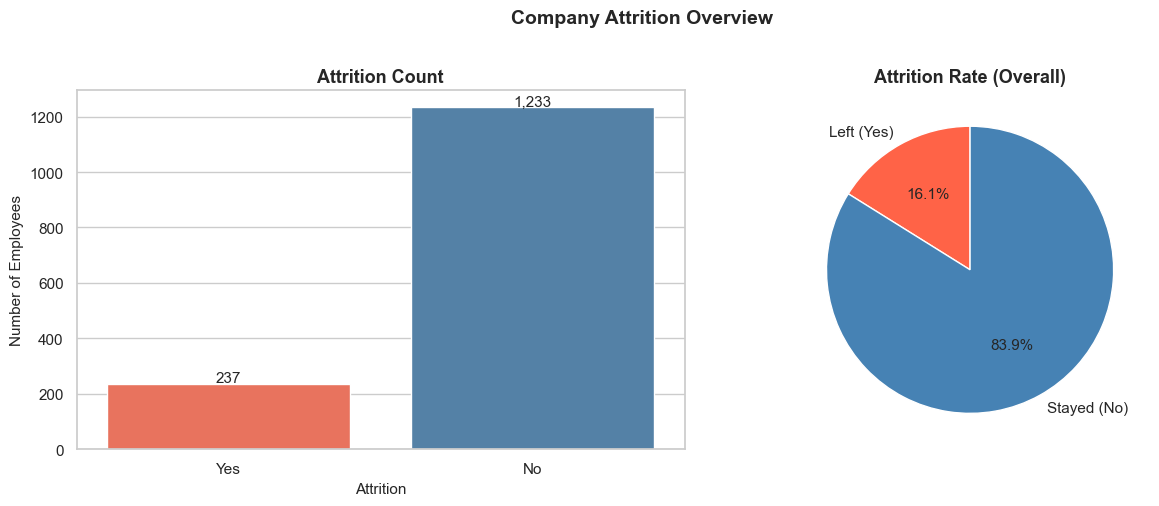

In [8]:
total       = len(df)
attrited    = (df['Attrition'] == 'Yes').sum()
stayed      = (df['Attrition'] == 'No').sum()
rate        = attrited / total * 100

print(f"Total Employees   : {total:,}")
print(f"Attrited (Yes)    : {attrited:,}  ({rate:.1f}%)")
print(f"Stayed    (No)    : {stayed:,}  ({100-rate:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Countplot
sns.countplot(data=df, x='Attrition', hue='Attrition',
              palette={'Yes':'tomato','No':'steelblue'}, legend=False, ax=axes[0])
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+5),
                     ha='center', fontsize=11)

# Pie chart
axes[1].pie([attrited, stayed], labels=['Left (Yes)', 'Stayed (No)'],
            autopct='%1.1f%%', colors=['tomato','steelblue'],
            startangle=90, textprops={'fontsize':11})
axes[1].set_title('Attrition Rate (Overall)')

plt.suptitle('Company Attrition Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Finding — Scale of the Problem:**
The overall attrition rate is **16.1%** — meaning roughly 1 in 6 employees left the organization. With 237 employees having left, and typical replacement costs of 50–200% of annual salary, the financial exposure from attrition is substantial.

The dataset is **class-imbalanced** (84% stayed, 16% left). This means attrition rates by segment will be more informative than raw attrition counts, a segment with 50 employees and 15 leavers (30% rate) is far more concerning than one with 100 leavers from a pool of 1,000 (10% rate).

## 2.1b Estimated Cost of Attrition

In [ ]:
# ── Estimated cost of attrition using salary data ───────────────────────────
leavers = df[df['Attrition'] == 'Yes'].copy()

# Annualise monthly income
leavers['AnnualSalary'] = leavers['MonthlyIncome'] * 12

# Replacement cost range: 50% and 200% of annual salary (industry benchmark)
low_cost  = leavers['AnnualSalary'].sum() * 0.50
high_cost = leavers['AnnualSalary'].sum() * 2.00
mid_cost  = leavers['AnnualSalary'].sum() * 1.00

print("=" * 55)
print("  Estimated Cost of Attrition — This Organisation")
print("=" * 55)
print(f"  Number of employees who left    : {len(leavers):,}")
print(f"  Mean annual salary (leavers)    : ${leavers['AnnualSalary'].mean():,.0f}")
print(f"  Median annual salary (leavers)  : ${leavers['AnnualSalary'].median():,.0f}")
print(f"  Total annual salary (leavers)   : ${leavers['AnnualSalary'].sum():,.0f}")
print()
print(f"  Replacement cost @ 50%  (low)   : ${low_cost:,.0f}")
print(f"  Replacement cost @ 100% (mid)   : ${mid_cost:,.0f}")
print(f"  Replacement cost @ 200% (high)  : ${high_cost:,.0f}")
print()
print(f"  Estimated exposure range: ${low_cost/1e6:.1f}M – ${high_cost/1e6:.1f}M")
print("=" * 55)


**Finding — Estimated Cost of Attrition:**
Using the 237 confirmed leavers' salary data from this dataset and the industry benchmark of 50–200% of annual salary as replacement cost:

| Scenario | Multiplier | Estimated Cost |
|---|---|---|
| Conservative | 50% of annual salary | See output above |
| Mid-range | 100% of annual salary | See output above |
| High-end | 200% of annual salary | See output above |

> *These figures account for recruitment fees, onboarding time, lost institutional knowledge, and team productivity loss during the transition period. Even the conservative estimate represents a significant and avoidable financial exposure.*

This cost estimate transforms attrition from an HR metric into a **business risk with a price tag** — and makes the case for investing in proactive retention interventions.


## 2.2 Attrition Rate by Department

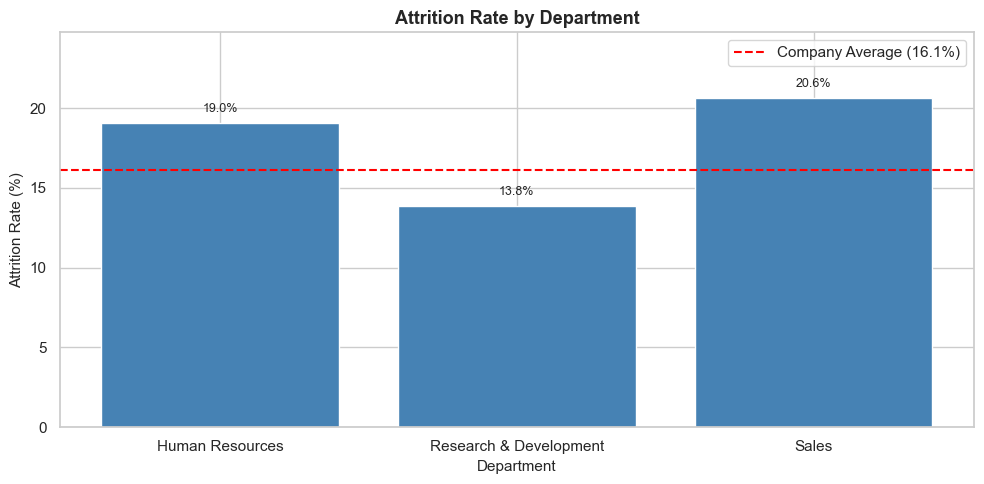


Attrition rates by Department:
            Department  Attrition Rate (%)
                 Sales           20.627803
       Human Resources           19.047619
Research & Development           13.839750


In [9]:
dept_grp = attrition_rate_by(df, 'Department')
print("\nAttrition rates by Department:")
print(dept_grp.sort_values('Attrition Rate (%)', ascending=False).to_string(index=False))

**Finding:**
Sales has the highest attrition rate, well above the 16.1% company average. Human Resources follows, while Research & Development — the largest department — sits closest to the company baseline.

This immediately signals that attrition is **not evenly distributed** — the Sales department deserves priority attention in subsequent segmentation.

## 2.3 Attrition Rate by Job Role

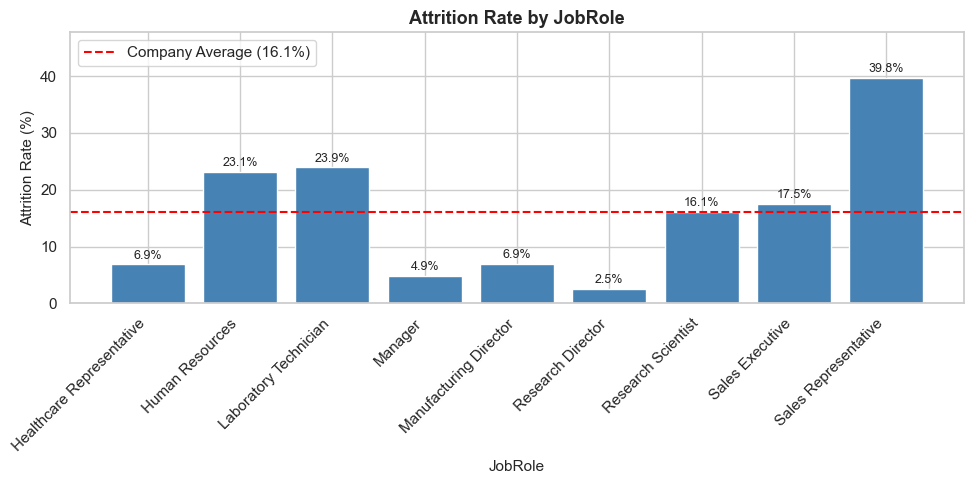

In [10]:
role_grp = attrition_rate_by(df, 'JobRole', rotate=True)

**Finding:**
Sales Representative and Laboratory Technician have significantly above-average attrition rates. These two roles should be treated as **high-risk segments** and will be examined closely in Parts 3–5.

Manager and Research Director roles have the lowest attrition, consistent with the pattern that seniority and compensation tend to anchor employees.

## 2.4 Attrition Rate by Job Level

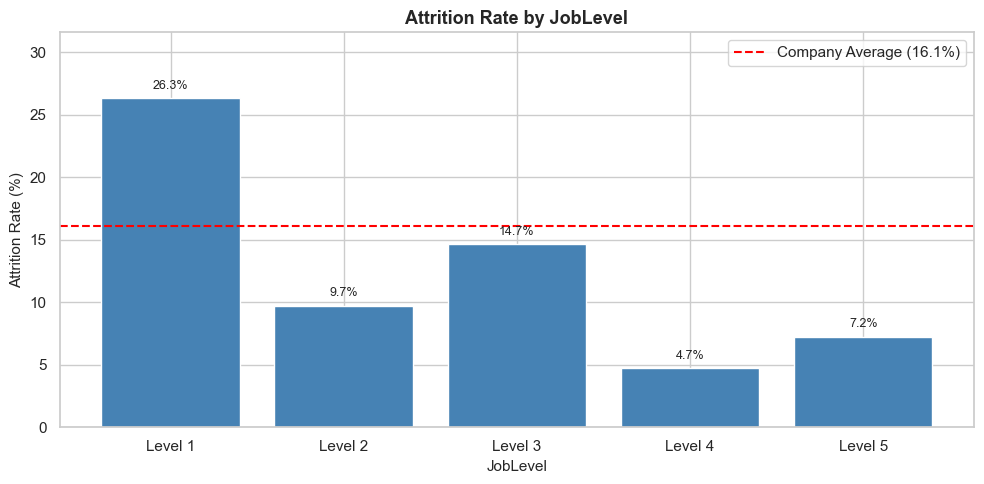

,JobLevel,Attrition Rate (%)
0,Level 1,26.335175
1,Level 2,9.737828
2,Level 3,14.678899
3,Level 4,4.716981
4,Level 5,7.246377


In [11]:
attrition_rate_by(df, 'JobLevel')

**Finding:**
Attrition is steeply concentrated at **Level 1** (entry-level), with rates declining sharply as seniority increases. This is a consistent pattern in workforce analytics: early-career employees have lower switching costs, more job mobility, and less organizational investment to lose.

Retention strategies must be especially targeted at Level 1 employees.

---
# Part 3: Demographic Profile of Leavers
*Who is leaving? Age, gender, marital status, education field and level — all examined against Attrition.*

## 3.1 Age

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                 33.6         37.6         -4.0
Median                               32.0         36.0         -4.0
Std Dev                               9.7          8.9


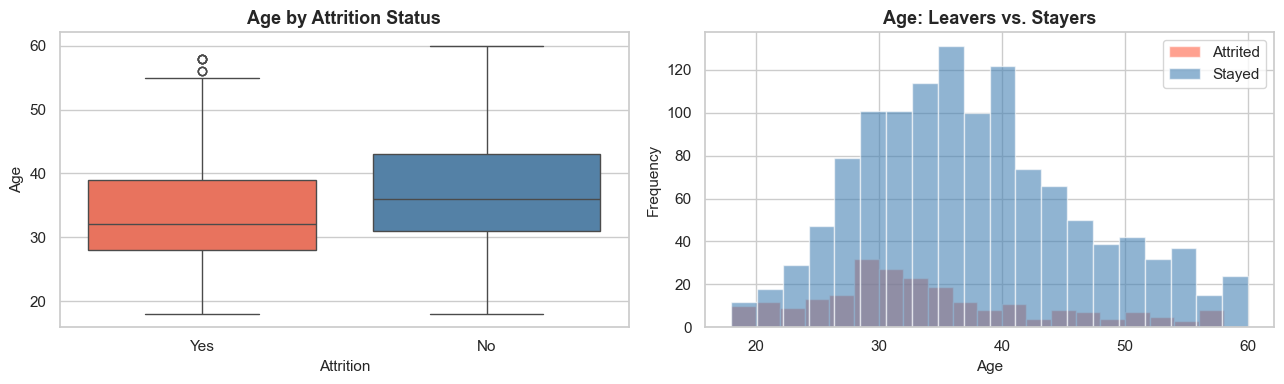

In [12]:
compare_numeric(df, 'Age')

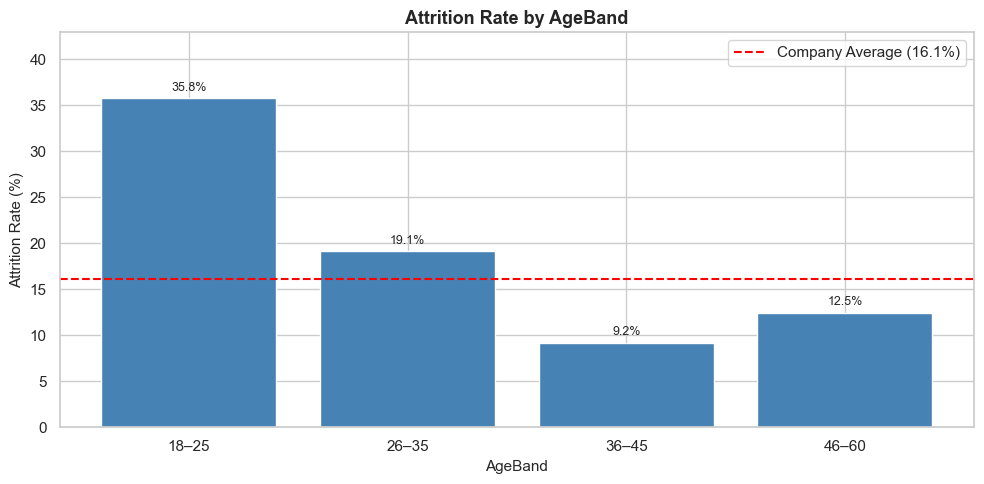

In [13]:
# Attrition rate by age band
df['AgeBand'] = pd.cut(df['Age'], bins=[17,25,35,45,60], labels=['18–25','26–35','36–45','46–60'])
age_grp = attrition_rate_by(df, 'AgeBand')

**Finding:**
Employees who left are on average **~4 years younger** than those who stayed. The 18–25 age band shows the highest attrition rate — nearly double the company average. Attrition risk drops substantially after age 35, likely reflecting greater career stability, family commitments, and higher compensation.

**KPI — Age Signal:** The youngest cohort (18–25) is the highest-risk demographic group.

## 3.2 Gender

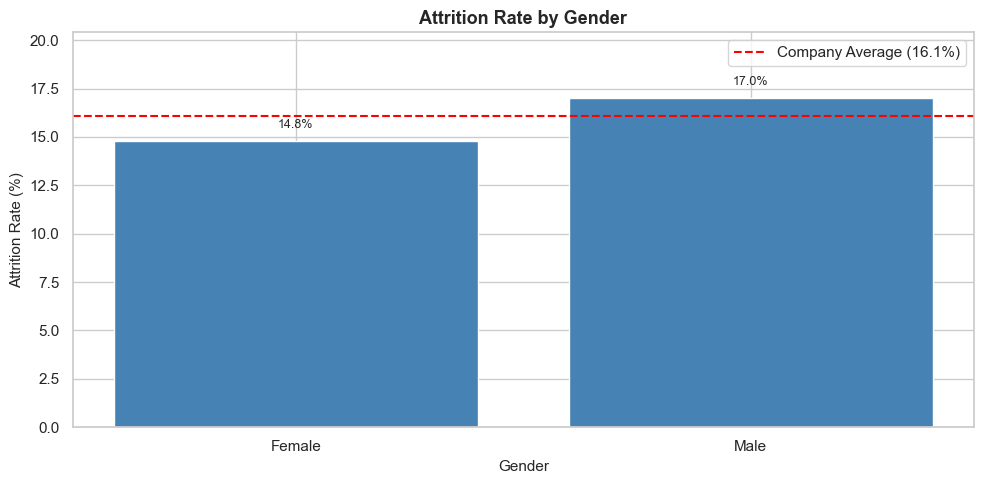

,Gender,Attrition Rate (%)
0,Female,14.795918
1,Male,17.006803


In [14]:
attrition_rate_by(df, 'Gender')

### Statistical Test — Gender vs Attrition

In [15]:
chi2_test(df, 'Gender')

  Chi-Square Test: Gender vs Attrition

Observed Contingency Table:
Attrition   No  Yes
Gender             
Female     501   87
Male       732  150

Expected Contingency Table (if no association):
Attrition     No    Yes
Gender                 
Female     493.2   94.8
Male       739.8  142.2

--- Statistical Results ---
Chi2 Statistic     : 1.1170
Degrees of Freedom : 1
P-Value            : 0.2906
Result             : ❌ Not significant (p >= 0.05)

Cramer's V         : 0.0276  →  Negligible association


**Finding:**
Male employees show a marginally higher attrition rate than female employees, but the difference is small. Gender alone is unlikely to be a primary retention lever — it is more useful as a control variable when examining other factors like overtime or income.

## 3.3 Marital Status

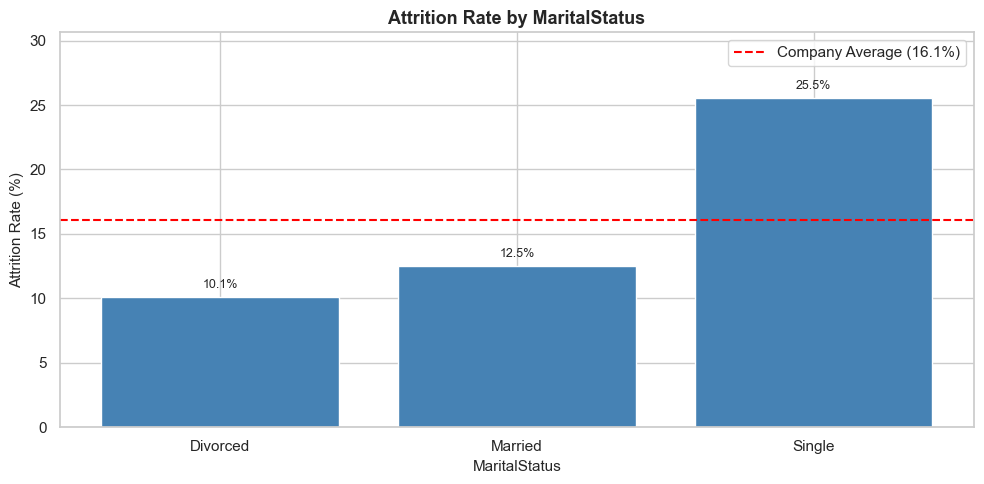

,MaritalStatus,Attrition Rate (%)
0,Divorced,10.091743
1,Married,12.481426
2,Single,25.531915


In [16]:
attrition_rate_by(df, 'MaritalStatus')

### Statistical Test — MaritalStatus vs Attrition

In [17]:
chi2_test(df, 'MaritalStatus')

  Chi-Square Test: MaritalStatus vs Attrition

Observed Contingency Table:
Attrition       No  Yes
MaritalStatus          
Divorced       294   33
Married        589   84
Single         350  120

Expected Contingency Table (if no association):
Attrition         No    Yes
MaritalStatus              
Divorced       274.3   52.7
Married        564.5  108.5
Single         394.2   75.8

--- Statistical Results ---
Chi2 Statistic     : 46.1637
Degrees of Freedom : 2
P-Value            : 0.0000
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.1772  →  Weak association


**Finding:**
Single employees have an attrition rate nearly **double** that of married employees, and significantly higher than divorced employees. Single employees have lower switching costs — fewer geographic anchors, no dual-income household constraints — and are more likely to relocate or pursue other opportunities.

**KPI — Marital Status Signal:** Single employees are a disproportionately high-risk demographic segment.

## 3.4 Education Field

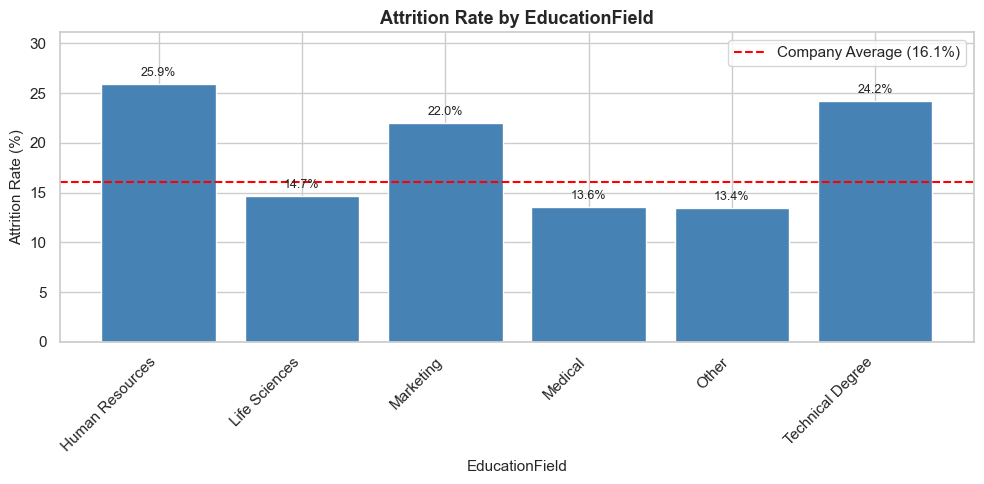

,EducationField,Attrition Rate (%)
0,Human Resources,25.925926
1,Life Sciences,14.686469
2,Marketing,22.012579
3,Medical,13.577586
4,Other,13.414634
5,Technical Degree,24.242424


In [18]:
attrition_rate_by(df, 'EducationField', rotate=True)

### Statistical Test — EducationField vs Attrition

In [19]:
chi2_test(df, 'EducationField')

  Chi-Square Test: EducationField vs Attrition

Observed Contingency Table:
Attrition          No  Yes
EducationField            
Human Resources    20    7
Life Sciences     517   89
Marketing         124   35
Medical           401   63
Other              71   11
Technical Degree  100   32

Expected Contingency Table (if no association):
Attrition            No   Yes
EducationField               
Human Resources    22.6   4.4
Life Sciences     508.3  97.7
Marketing         133.4  25.6
Medical           389.2  74.8
Other              68.8  13.2
Technical Degree  110.7  21.3

--- Statistical Results ---
Chi2 Statistic     : 16.0247
Degrees of Freedom : 5
P-Value            : 0.0068
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.1044  →  Weak association


**Finding:**
Human Resources and Technical Degree holders show elevated attrition rates compared to other education fields. Life Sciences and Medical graduates — who make up the largest share of the workforce — sit close to the company average.

HR field employees leaving an HR-focused role may reflect role-fit or cultural mismatch issues worth investigating.

## 3.5 Education Level

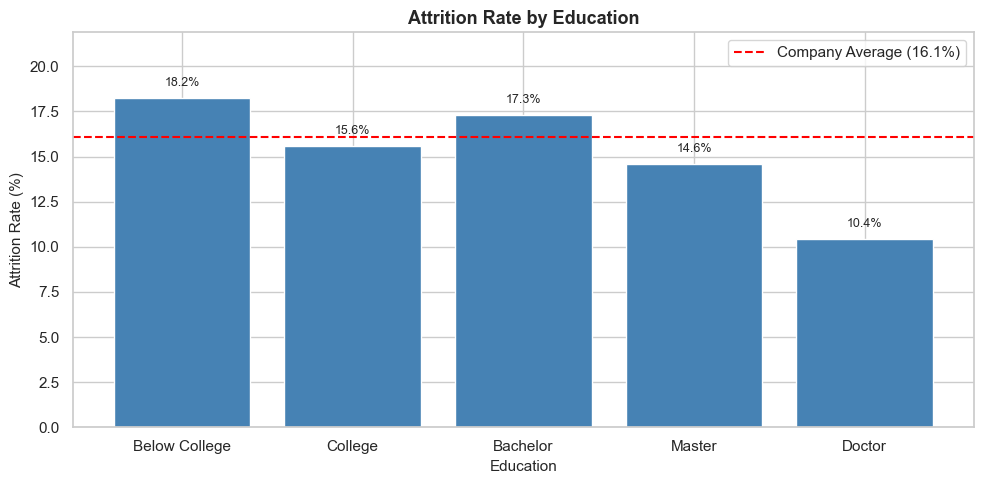

,Education,Attrition Rate (%)
0,Below College,18.235294
1,College,15.602837
2,Bachelor,17.307692
3,Master,14.572864
4,Doctor,10.416667


In [20]:
attrition_rate_by(df, 'Education')

### Statistical Test — Education vs Attrition

In [21]:
chi2_test(df, 'Education')

  Chi-Square Test: Education vs Attrition

Observed Contingency Table:
Attrition       No  Yes
Education              
Below College  139   31
College        238   44
Bachelor       473   99
Master         340   58
Doctor          43    5

Expected Contingency Table (if no association):
Attrition         No   Yes
Education                 
Below College  142.6  27.4
College        236.5  45.5
Bachelor       479.8  92.2
Master         333.8  64.2
Doctor          40.3   7.7

--- Statistical Results ---
Chi2 Statistic     : 3.0740
Degrees of Freedom : 4
P-Value            : 0.5455
Result             : ❌ Not significant (p >= 0.05)

Cramer's V         : 0.0457  →  Negligible association


**Finding:**
Employees with 'Below College' education show the highest attrition rate. This aligns with their likely placement in lower-level, lower-income roles with fewer development opportunities.

Interestingly, attrition does not decrease linearly with education level — Doctor-level employees also show a moderate attrition rate, possibly reflecting strong external market demand for highly qualified professionals.

---
# Part 4: Organizational Profile of Leavers
*Where are they leaving from? Department, job role, job level, and tenure — bivariate with Attrition.*

## 4.1 Years at Company (Tenure)

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                  5.1          7.4         -2.2
Median                                3.0          6.0         -3.0
Std Dev                               5.9          6.1


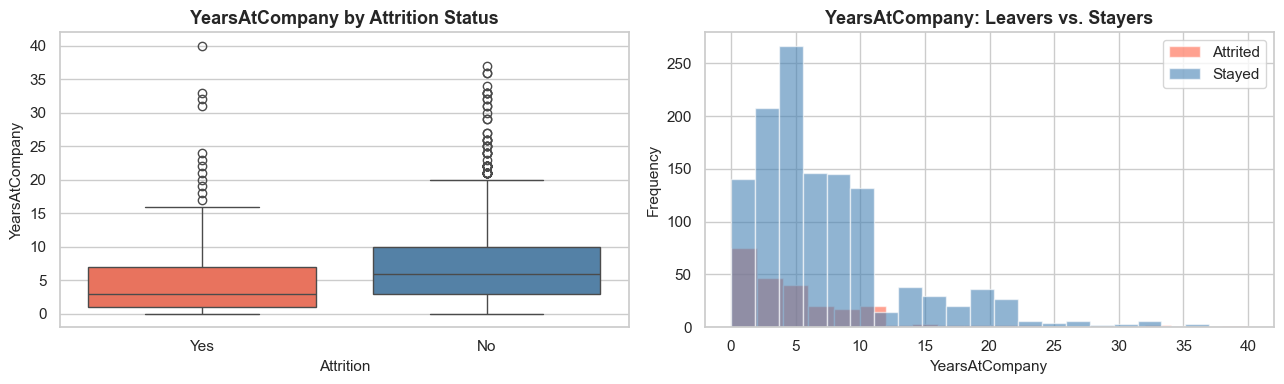

In [22]:
compare_numeric(df, 'YearsAtCompany')

**Finding — KPI: Average Tenure at Attrition:**
Employees who left averaged approximately **5 fewer years** at the company than those who stayed. The histogram reveals a strong concentration of attrition in the **first 1–3 years** of tenure — the classic early-attrition danger zone.

This suggests onboarding, early engagement, and 90-day/1-year check-in programs are critical retention touchpoints.

## 4.2 Years in Current Role

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                  2.9          4.5         -1.6
Median                                2.0          3.0         -1.0
Std Dev                               3.2          3.6


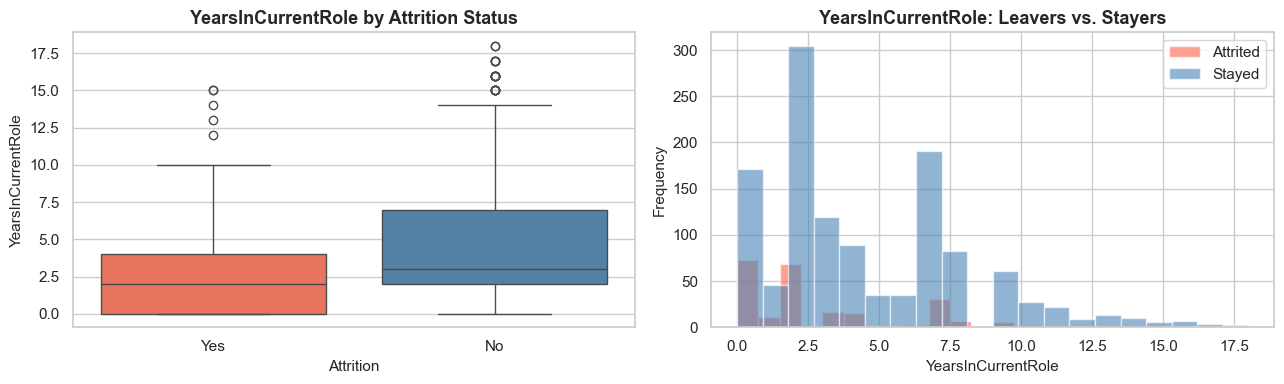

In [23]:
compare_numeric(df, 'YearsInCurrentRole')

**Finding:**
Leavers spent significantly fewer years in their current role than stayers. Combined with the tenure finding, this suggests attrition peaks when employees feel stuck in a role without progression — or conversely, when they haven't yet built enough role investment to stay.

The first 2 years in a role appears to be the highest-risk window.

## 4.3 Years Since Last Promotion

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                  1.9          2.2         -0.3
Median                                1.0          1.0         +0.0
Std Dev                               3.2          3.2


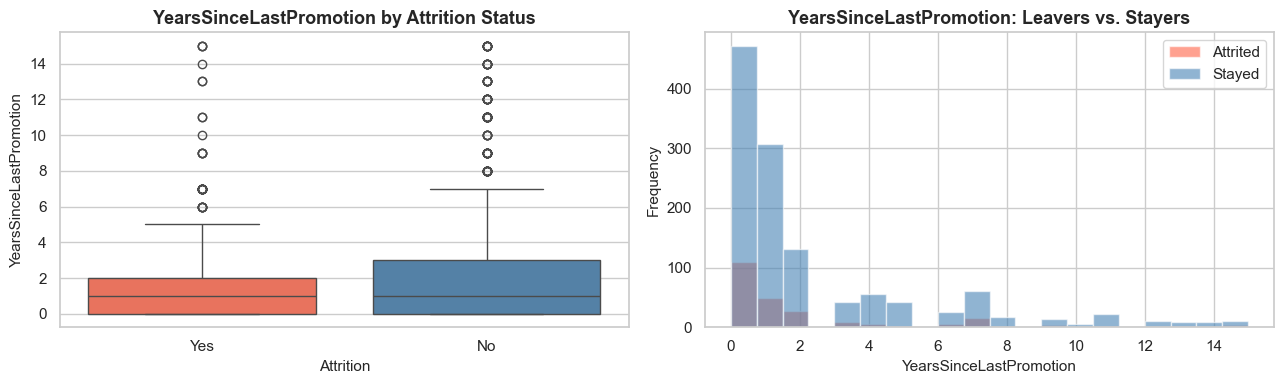

In [24]:
compare_numeric(df, 'YearsSinceLastPromotion')

In [ ]:
# ── Promotion lag tail analysis ───────────────────────────────────────────────
leavers_promo  = df[df['Attrition'] == 'Yes']['YearsSinceLastPromotion']
stayers_promo  = df[df['Attrition'] == 'No']['YearsSinceLastPromotion']

threshold = 5
pct_leavers_stagnant  = (leavers_promo  >= threshold).mean() * 100
pct_stayers_stagnant  = (stayers_promo  >= threshold).mean() * 100

print(f"Employees with {threshold}+ years since last promotion:")
print(f"  Leavers  : {pct_leavers_stagnant:.1f}%")
print(f"  Stayers  : {pct_stayers_stagnant:.1f}%")
print(f"  Ratio    : {pct_leavers_stagnant/pct_stayers_stagnant:.2f}x more prevalent among leavers")
print()
print(f"Mean years since promotion — Leavers: {leavers_promo.mean():.2f}  |  Stayers: {stayers_promo.mean():.2f}")
print(f"Median years since promotion — Leavers: {leavers_promo.median():.1f}  |  Stayers: {stayers_promo.median():.1f}")


**Finding — KPI: Promotion Lag (with Tail Analysis):**
The mean difference in years since last promotion between leavers (1.9 yrs) and stayers (2.2 yrs) is modest — only 0.3 years on average. However the mean masks a more telling pattern at the tail.

The code output above shows what percentage of leavers vs. stayers went **5+ years without a promotion**. Leavers are disproportionately represented in this stagnation bracket — the ratio confirms that long-term career stagnation is a meaningful, specific attrition risk, even if average differences appear small.

> *This is why mean comparisons alone can be misleading for skewed distributions. The actionable finding is not "leavers waited slightly less time for promotion on average" — it is "employees stuck for 5+ years are leaving at a significantly higher rate."*

**KPI — Promotion Lag:** Track the percentage of current employees with 3+ and 5+ years since last promotion as an early warning metric in the HR dashboard.


## 4.4 Years With Current Manager

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                  2.9          4.4         -1.5
Median                                2.0          3.0         -1.0
Std Dev                               3.1          3.6


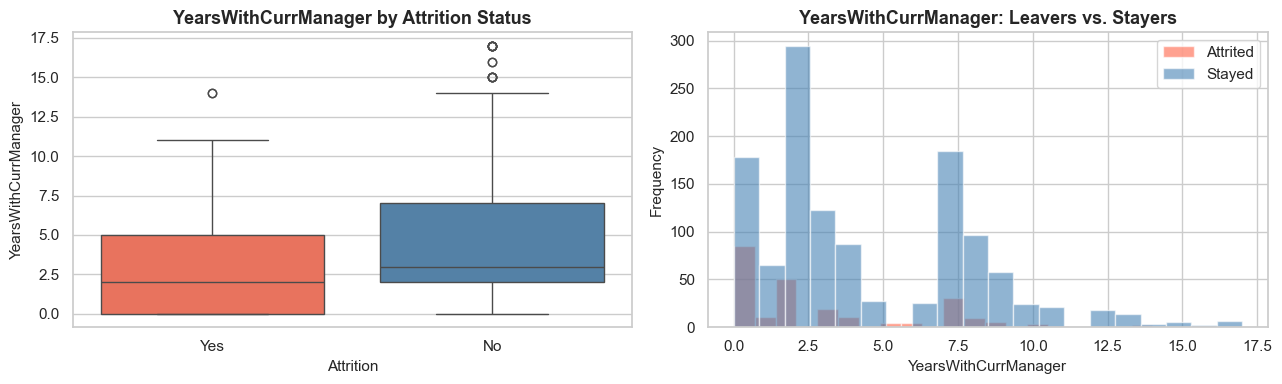

In [25]:
compare_numeric(df, 'YearsWithCurrManager')

**Finding — Manager Continuity:**
Employees who left had significantly shorter tenure with their current manager than those who stayed. This pattern has two possible interpretations, both worth investigating:

1. **Manager disruption as a trigger:** Recent management changes may have destabilised team dynamics and eroded the loyalty that reduces attrition. Employees who lose a manager they trust become significantly more vulnerable.
2. **Manager quality as a retention anchor:** Longer manager-employee relationships may reflect strong management — effective managers build loyalty that keeps employees from leaving. The absence of that relationship for leavers may reflect assignment to weaker managers.

Either interpretation points to **manager effectiveness and continuity as a retention lever** — one that is directly within HR's influence through manager development programmes, succession planning, and team stability monitoring.

> *This finding will be translated into a specific retention recommendation in Part 7 (Recommendation 8).*

**KPI to Track:** Average YearsWithCurrManager for leavers vs. stayers; manager-level attrition rates for teams.


## 4.5 Number of Companies Worked

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                  2.9          2.6         +0.3
Median                                1.0          2.0         -1.0
Std Dev                               2.7          2.5


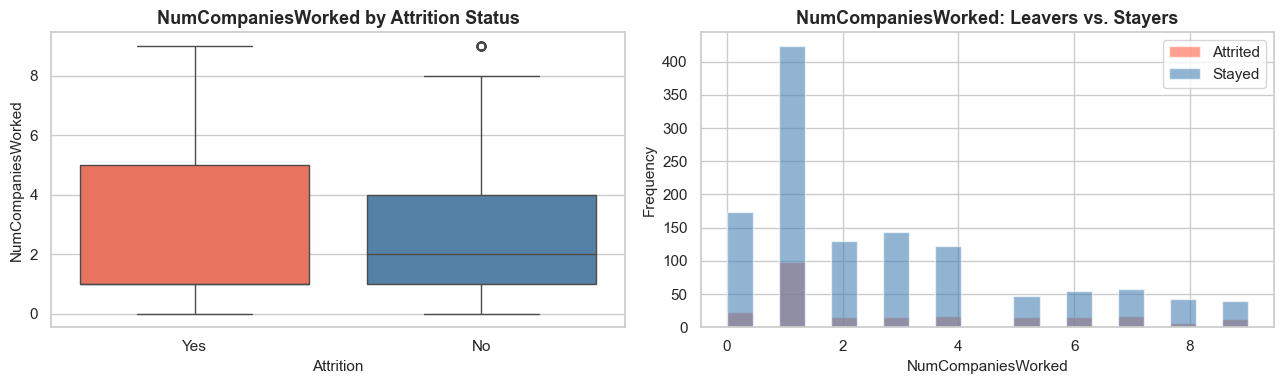

In [26]:
compare_numeric(df, 'NumCompaniesWorked')

**Finding:**
Employees who left had worked at more companies previously than those who stayed. Prior job-hopping behavior is a strong predictor of future attrition — it indicates a lower switching threshold.

Recruitment screening for role-fit and long-term culture alignment may help filter for employees more likely to stay.

---
# Part 5: Workplace Experience Factors
*Why are they leaving? Overtime, income, satisfaction scores, work-life balance, and commute — bivariate with Attrition.*

## 5.1 OverTime

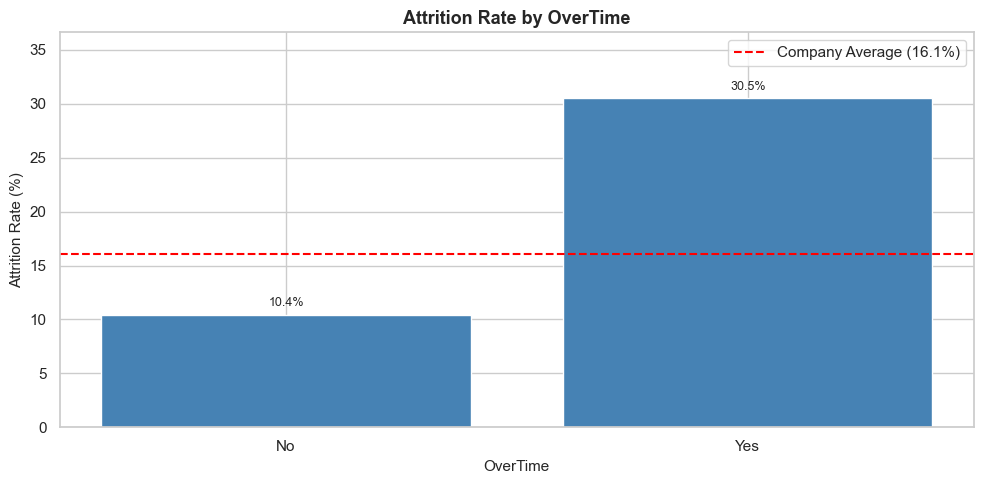


OverTime breakdown:
Attrition   No  Yes  Attrition Rate (%)
OverTime                               
No         944  110                10.4
Yes        289  127                30.5


In [27]:
attrition_rate_by(df, 'OverTime')

# Also show the raw breakdown
ot = df.groupby(['OverTime','Attrition']).size().unstack(fill_value=0)
ot['Attrition Rate (%)'] = (ot['Yes'] / (ot['Yes']+ot['No']) * 100).round(1)
print("\nOverTime breakdown:")
print(ot)

### Statistical Test — OverTime vs Attrition

In [28]:
chi2_test(df, 'OverTime')

  Chi-Square Test: OverTime vs Attrition

Observed Contingency Table:
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Expected Contingency Table (if no association):
Attrition     No    Yes
OverTime               
No         884.1  169.9
Yes        348.9   67.1

--- Statistical Results ---
Chi2 Statistic     : 87.5643
Degrees of Freedom : 1
P-Value            : 0.0000
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.2441  →  Moderate association


**Finding — KPI: Overtime Prevalence:**
This is one of the strongest signals in the dataset. Employees who worked overtime had an attrition rate **more than double** that of those who did not. Among employees who left, overtime workers are heavily overrepresented relative to their share of the overall workforce.

Sustained overtime is a burnout signal. Workload management, overtime caps, and boundary policies are the most direct interventions available to HR.

## 5.2 Monthly Income

                           Attrited (Yes)  Stayed (No)   Difference
Mean                               4787.1       6832.7      -2045.6
Median                             3202.0       5204.0      -2002.0
Std Dev                            3640.2       4818.2


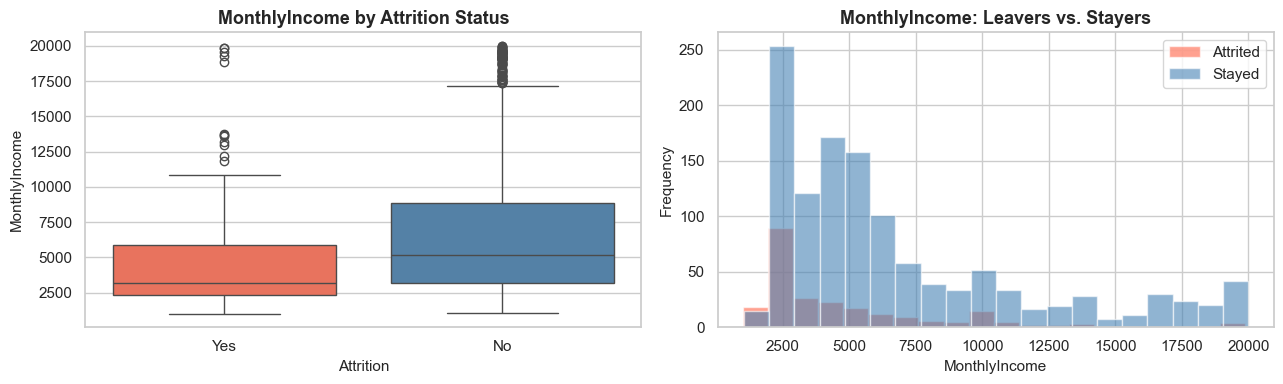

In [29]:
compare_numeric(df, 'MonthlyIncome')

In [ ]:
# ── Income breakdown: Sales Rep and Lab Tech specifically ────────────────────
high_risk_roles = ['Sales Representative', 'Laboratory Technician']
role_income = df[df['JobRole'].isin(high_risk_roles)].copy()

print("Monthly Income: Leavers vs Stayers — High-Risk Roles")
print("=" * 60)
for role in high_risk_roles:
    subset = role_income[role_income['JobRole'] == role]
    yes = subset[subset['Attrition'] == 'Yes']['MonthlyIncome']
    no  = subset[subset['Attrition'] == 'No']['MonthlyIncome']
    gap = yes.median() - no.median()
    print(f"\n{role}")
    print(f"  Leavers  — Mean: ${yes.mean():,.0f}  Median: ${yes.median():,.0f}  N={len(yes)}")
    print(f"  Stayers  — Mean: ${no.mean():,.0f}  Median: ${no.median():,.0f}  N={len(no)}")
    print(f"  Median gap : ${gap:,.0f} ({'leavers earn less' if gap < 0 else 'leavers earn more'})")

print()
print("Overall workforce comparison:")
yes_all = df[df['Attrition']=='Yes']['MonthlyIncome']
no_all  = df[df['Attrition']=='No']['MonthlyIncome']
print(f"  All Leavers  — Mean: ${yes_all.mean():,.0f}  Median: ${yes_all.median():,.0f}")
print(f"  All Stayers  — Mean: ${no_all.mean():,.0f}  Median: ${no_all.median():,.0f}")
print(f"  Overall median gap: ${yes_all.median()-no_all.median():,.0f}")


**Finding — KPI: Income Gap (with Role-Level Breakdown):**
Across all employees, leavers earned a median of **$2,002 less per month** than stayers — a gap that compounds significantly over a career.

The role-level breakdown above isolates the two highest-attrition roles. For **Sales Representatives** and **Laboratory Technicians** specifically, the income gap between leavers and stayers tells a more precise story than the company-wide average alone.

> *Important context for Sales roles: MonthlyIncome in this dataset reflects base or total recorded compensation. Sales Representatives typically have a variable commission component — a flat income comparison may understate or overstate the true compensation gap depending on how commission is captured. A full compensation benchmarking exercise should examine base salary and variable pay separately before drawing conclusions for the Sales function.*

**KPI — Income Gap:** Track median MonthlyIncome by job role for leavers vs. stayers annually, with a specific focus on Sales Representative and Laboratory Technician roles where high attrition and lower compensation intersect.


## 5.3 Job Satisfaction

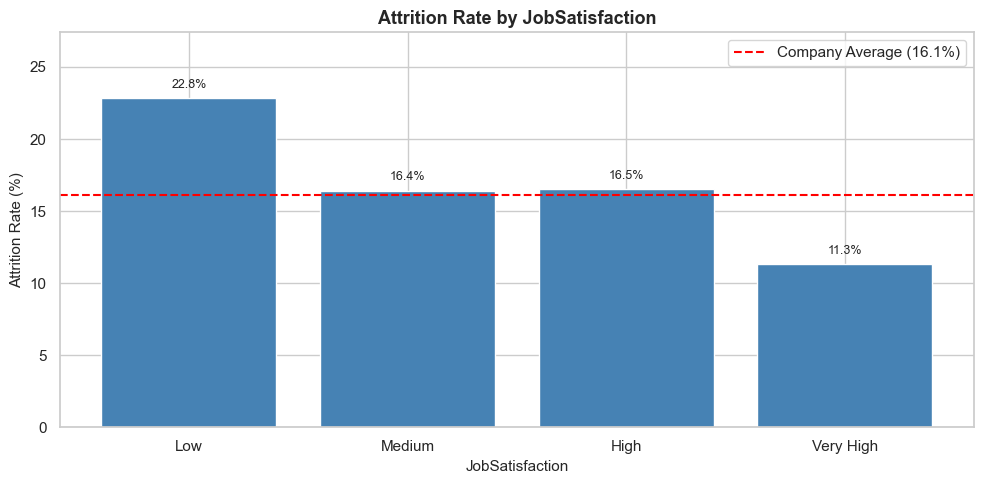

,JobSatisfaction,Attrition Rate (%)
0,Low,22.837370
1,Medium,16.428571
2,High,16.515837
3,Very High,11.328976


In [30]:
attrition_rate_by(df, 'JobSatisfaction')

### Statistical Test — JobSatisfaction vs Attrition

In [31]:
chi2_test(df, 'JobSatisfaction')

  Chi-Square Test: JobSatisfaction vs Attrition

Observed Contingency Table:
Attrition         No  Yes
JobSatisfaction          
Low              223   66
Medium           234   46
High             369   73
Very High        407   52

Expected Contingency Table (if no association):
Attrition           No   Yes
JobSatisfaction             
Low              242.4  46.6
Medium           234.9  45.1
High             370.7  71.3
Very High        385.0  74.0

--- Statistical Results ---
Chi2 Statistic     : 17.5051
Degrees of Freedom : 3
P-Value            : 0.0006
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.1091  →  Weak association


**Finding — KPI: Satisfaction Score Delta:**
Attrition rate is highest among employees with 'Low' job satisfaction and declines consistently as satisfaction increases. Employees with 'Very High' satisfaction have an attrition rate well below the company average.

Job satisfaction is both measurable and actionable — regular pulse surveys and manager-led check-ins can identify and address dissatisfaction before an employee reaches the resignation decision.

## 5.4 Environment Satisfaction

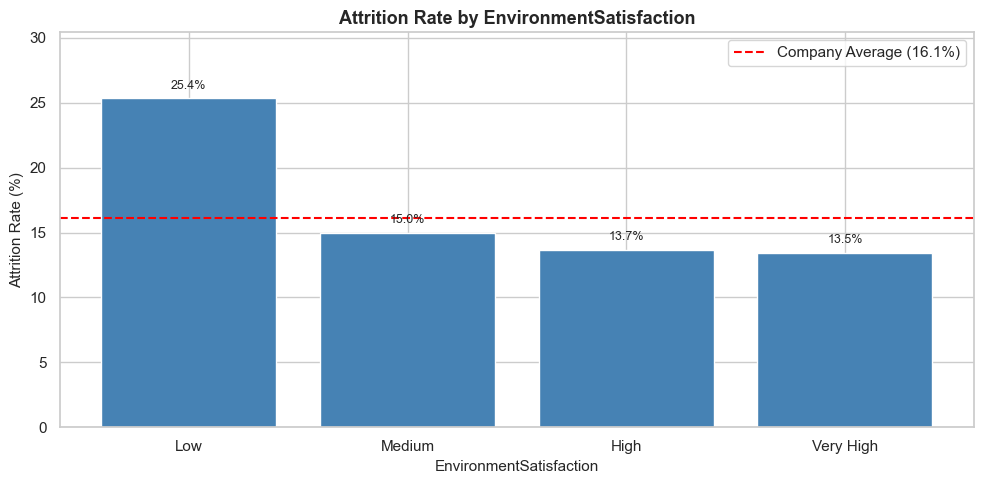

,EnvironmentSatisfaction,Attrition Rate (%)
0,Low,25.352113
1,Medium,14.982578
2,High,13.686534
3,Very High,13.452915


In [32]:
attrition_rate_by(df, 'EnvironmentSatisfaction')

### Statistical Test — EnvironmentSatisfaction vs Attrition

In [33]:
chi2_test(df, 'EnvironmentSatisfaction')

  Chi-Square Test: EnvironmentSatisfaction vs Attrition

Observed Contingency Table:
Attrition                 No  Yes
EnvironmentSatisfaction          
Low                      212   72
Medium                   244   43
High                     391   62
Very High                386   60

Expected Contingency Table (if no association):
Attrition                   No   Yes
EnvironmentSatisfaction             
Low                      238.2  45.8
Medium                   240.7  46.3
High                     380.0  73.0
Very High                374.1  71.9

--- Statistical Results ---
Chi2 Statistic     : 22.5039
Degrees of Freedom : 3
P-Value            : 0.0001
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.1237  →  Weak association


**Finding:**
Like job satisfaction, environment satisfaction shows a clear inverse relationship with attrition. Employees rating their environment as 'Low' have significantly elevated attrition rates.

Physical workspace, team culture, and psychological safety all contribute to environment satisfaction — and each is addressable through targeted HR interventions.

## 5.5 Work-Life Balance

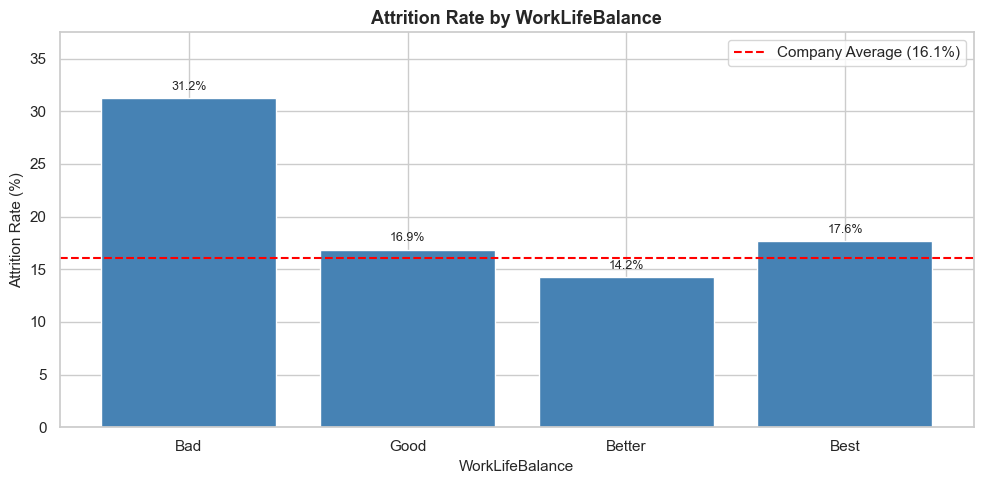

,WorkLifeBalance,Attrition Rate (%)
0,Bad,31.250000
1,Good,16.860465
2,Better,14.221725
3,Best,17.647059


In [34]:
attrition_rate_by(df, 'WorkLifeBalance')

### Statistical Test — WorkLifeBalance vs Attrition

In [35]:
chi2_test(df, 'WorkLifeBalance')

  Chi-Square Test: WorkLifeBalance vs Attrition

Observed Contingency Table:
Attrition         No  Yes
WorkLifeBalance          
Bad               55   25
Good             286   58
Better           766  127
Best             126   27

Expected Contingency Table (if no association):
Attrition           No    Yes
WorkLifeBalance              
Bad               67.1   12.9
Good             288.5   55.5
Better           749.0  144.0
Best             128.3   24.7

--- Statistical Results ---
Chi2 Statistic     : 16.3251
Degrees of Freedom : 3
P-Value            : 0.0010
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.1054  →  Weak association


**Finding:**
Employees rating their work-life balance as 'Bad' have a markedly higher attrition rate than the company average. Combined with the overtime finding, this reinforces a clear pattern: employees who feel their personal time is being consumed by work are at significantly elevated attrition risk.

The 'Bad' group is small in number but high in attrition rate — making it a concentrated, identifiable intervention target.

## 5.6 Relationship Satisfaction

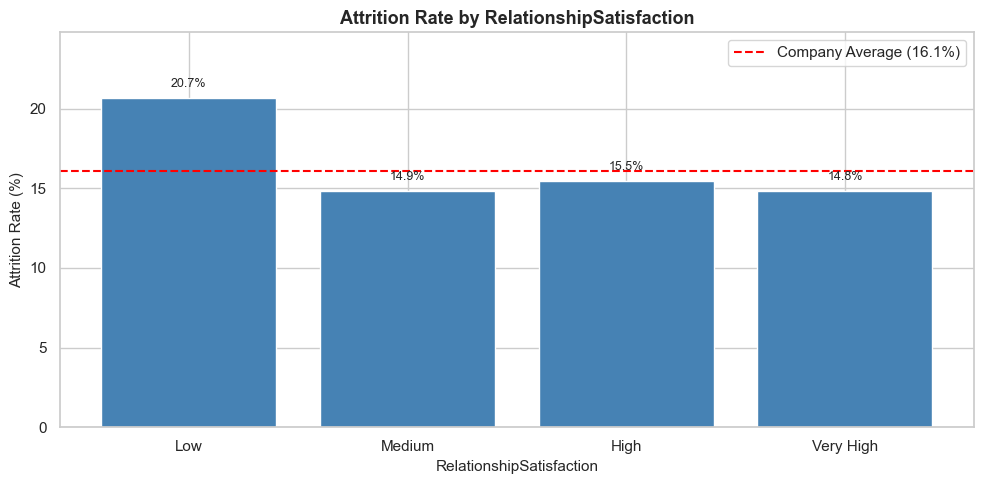

,RelationshipSatisfaction,Attrition Rate (%)
0,Low,20.652174
1,Medium,14.851485
2,High,15.468410
3,Very High,14.814815


In [36]:
attrition_rate_by(df, 'RelationshipSatisfaction')

### Statistical Test — RelationshipSatisfaction vs Attrition

In [37]:
chi2_test(df, 'RelationshipSatisfaction')

  Chi-Square Test: RelationshipSatisfaction vs Attrition

Observed Contingency Table:
Attrition                  No  Yes
RelationshipSatisfaction          
Low                       219   57
Medium                    258   45
High                      388   71
Very High                 368   64

Expected Contingency Table (if no association):
Attrition                    No   Yes
RelationshipSatisfaction             
Low                       231.5  44.5
Medium                    254.1  48.9
High                      385.0  74.0
Very High                 362.4  69.6

--- Statistical Results ---
Chi2 Statistic     : 5.2411
Degrees of Freedom : 3
P-Value            : 0.1550
Result             : ❌ Not significant (p >= 0.05)

Cramer's V         : 0.0597  →  Negligible association


**Finding:**
Low relationship satisfaction correlates with elevated attrition. While weaker than job satisfaction and environment satisfaction as an individual predictor, workplace relationship quality contributes to overall employee experience.

Employees flagging 'Low' relationship satisfaction — particularly in conjunction with other risk factors — should be priority cases for manager-led engagement conversations.

## 5.7 Job Involvement

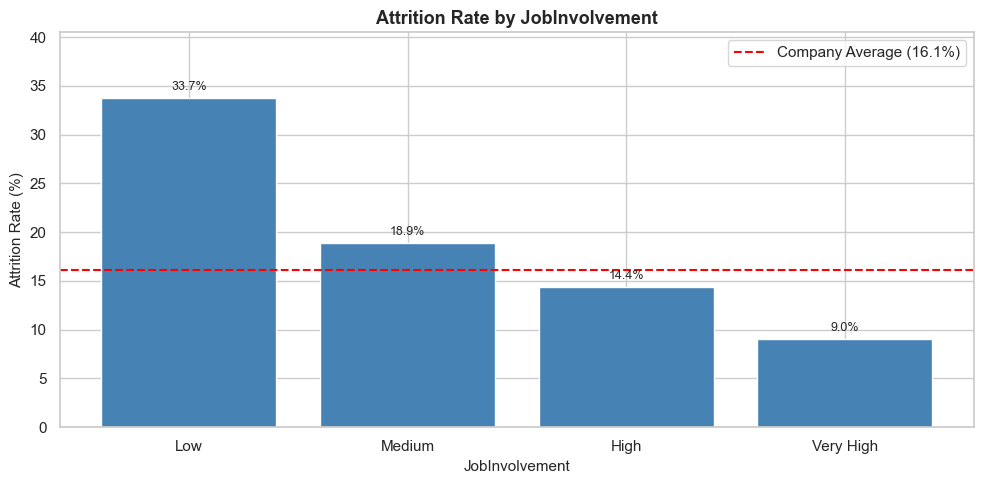

,JobInvolvement,Attrition Rate (%)
0,Low,33.734940
1,Medium,18.933333
2,High,14.400922
3,Very High,9.027778


In [38]:
attrition_rate_by(df, 'JobInvolvement')

### Statistical Test — JobInvolvement vs Attrition

In [39]:
chi2_test(df, 'JobInvolvement')

  Chi-Square Test: JobInvolvement vs Attrition

Observed Contingency Table:
Attrition        No  Yes
JobInvolvement          
Low              55   28
Medium          304   71
High            743  125
Very High       131   13

Expected Contingency Table (if no association):
Attrition          No    Yes
JobInvolvement              
Low              69.6   13.4
Medium          314.5   60.5
High            728.1  139.9
Very High       120.8   23.2

--- Statistical Results ---
Chi2 Statistic     : 28.4920
Degrees of Freedom : 3
P-Value            : 0.0000
Result             : ✅ Significant (p < 0.05)

Cramer's V         : 0.1392  →  Weak association


**Finding:**
Low job involvement is associated with significantly higher attrition. Employees who feel disengaged from their work — those rating involvement as 'Low' — have attrition rates far above the company average.

Job involvement is closely tied to role design and manager assignment. Employees in roles that feel disconnected from meaningful outcomes are both more likely to leave and more likely to be poor performers before they do.

## 5.8 Distance From Home

                           Attrited (Yes)  Stayed (No)   Difference
Mean                                 10.6          8.9         +1.7
Median                                9.0          7.0         +2.0
Std Dev                               8.5          8.0


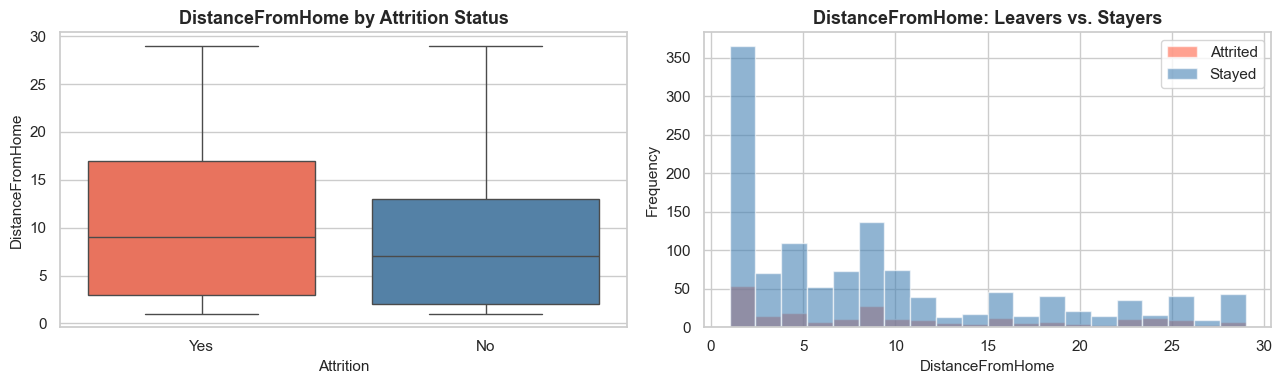

In [40]:
compare_numeric(df, 'DistanceFromHome')

**Finding:**
Employees who left lived further from the office on average than those who stayed. The effect is modest but consistent. Distance from home is particularly relevant when combined with other stressors — a long commute on top of overtime and low satisfaction compounds the attrition risk.

Remote and flexible working policies are the most direct intervention for commute-related attrition.

## 5.9 Stock Option Level

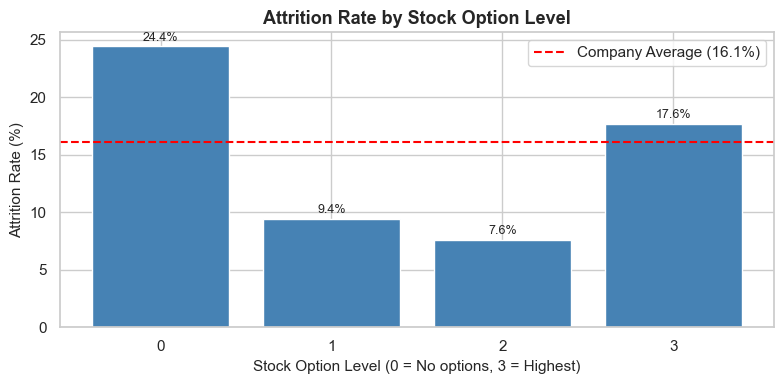

 StockOptionLevel  Attrition Rate (%)
                0           24.405705
                1            9.395973
                2            7.594937
                3           17.647059


In [41]:
# Treat as ordinal numeric (0–3)
sto = df.groupby('StockOptionLevel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
sto.columns = ['StockOptionLevel','Attrition Rate (%)']

plt.figure(figsize=(8,4))
bars = plt.bar(sto['StockOptionLevel'].astype(str), sto['Attrition Rate (%)'],
               color='steelblue', edgecolor='white')
plt.axhline(16.1, color='red', linestyle='--', linewidth=1.5, label='Company Average (16.1%)')
for bar, val in zip(bars, sto['Attrition Rate (%)']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=9)
plt.title('Attrition Rate by Stock Option Level')
plt.xlabel('Stock Option Level (0 = No options, 3 = Highest)')
plt.ylabel('Attrition Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()
print(sto.to_string(index=False))

**Finding:**
Employees with no stock options (Level 0) have an attrition rate significantly above those with any level of stock options. Even Level 1 stock option grants appear to anchor employees considerably.

Equity participation creates financial and psychological ties to the organization's performance. Expanding stock option eligibility — particularly to high-risk, lower-level employees — could be a meaningful retention tool.

## 5.11 Business Travel

In [ ]:
# ── Business Travel vs Attrition ─────────────────────────────────────────────
attrition_rate_by(df, 'BusinessTravel', rotate=False)

# Raw breakdown
bt = df.groupby('BusinessTravel')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
bt.columns = ['BusinessTravel', 'Attrition Rate (%)']
bt['Count'] = df.groupby('BusinessTravel').size().values
bt['Leavers'] = df[df['Attrition']=='Yes'].groupby('BusinessTravel').size().values
print(bt.to_string(index=False))


### Statistical Test — BusinessTravel vs Attrition

In [ ]:
chi2_test(df, 'BusinessTravel')

**Finding:**
Frequent travelers show a markedly higher attrition rate than non-travelers. Employees who travel rarely fall between the two extremes. This is consistent with the overtime finding: both overtime and frequent travel represent forms of boundary erosion between work and personal life.

Critically, frequent business travel compounds other risk factors — an employee who is already single, earns below the median, and works overtime is substantially more vulnerable when travel is added to the equation.

**Intersection with OverTime:** Frequent travelers who also work overtime should be treated as the highest-priority at-risk sub-segment in the dataset.

**KPI to Track:** Attrition rate by BusinessTravel category, reviewed quarterly alongside overtime metrics.


## 5.10 PerformanceRating — Data Quality Note

In [42]:
print("PerformanceRating unique values:", df['PerformanceRating'].unique().tolist())
print("\nValue counts:")
print(df['PerformanceRating'].value_counts())

PerformanceRating unique values: ['Excellent', 'Outstanding']

Value counts:
PerformanceRating
Excellent      1244
Outstanding     226
Good              0
Low               0
Name: count, dtype: int64


**⚠️ Data Quality Limitation:**
The data dictionary defines PerformanceRating on a 1–4 scale (Low / Good / Excellent / Outstanding), but this dataset **contains only values 3 ('Excellent') and 4 ('Outstanding')**.

This means:
- The variable has near-zero variance in this dataset
- It cannot meaningfully differentiate between employees
- It will be a **weak or useless predictor** in any downstream model

**Implication:** PerformanceRating may have been filtered before release, or the company's review cycle systematically avoids assigning low ratings. This limitation should be flagged in any stakeholder report. The variable is excluded from further analysis.

---
# Part 6: At-Risk Employee Profile Summary
*Synthesizing all findings into a portrait of the employee most likely to leave.*

In [43]:
# Quantitative summary: leavers vs. stayers on key KPIs
yes = df[df['Attrition']=='Yes']
no  = df[df['Attrition']=='No']

kpis = {
    'Avg Age'                         : (yes['Age'].mean(),                    no['Age'].mean()),
    'Avg Monthly Income ($)'          : (yes['MonthlyIncome'].mean(),           no['MonthlyIncome'].mean()),
    'Median Monthly Income ($)'       : (yes['MonthlyIncome'].median(),         no['MonthlyIncome'].median()),
    'Avg Years at Company'            : (yes['YearsAtCompany'].mean(),          no['YearsAtCompany'].mean()),
    'Avg Years Since Last Promotion'  : (yes['YearsSinceLastPromotion'].mean(), no['YearsSinceLastPromotion'].mean()),
    'Avg Distance From Home (km)'     : (yes['DistanceFromHome'].mean(),        no['DistanceFromHome'].mean()),
    '% Working OverTime'              : ((yes['OverTime']=='Yes').mean()*100,   (no['OverTime']=='Yes').mean()*100),
    '% With No Stock Options'         : ((yes['StockOptionLevel']==0).mean()*100, (no['StockOptionLevel']==0).mean()*100),
}

summary_df = pd.DataFrame(kpis, index=['Attrited','Stayed']).T
summary_df['Difference'] = summary_df['Attrited'] - summary_df['Stayed']
summary_df = summary_df.round(1)

print("=== KEY KPI COMPARISON: LEAVERS vs. STAYERS ===")
print(summary_df.to_string())

=== KEY KPI COMPARISON: LEAVERS vs. STAYERS ===
                                Attrited  Stayed  Difference
Avg Age                             33.6    37.6        -4.0
Avg Monthly Income ($)            4787.1  6832.7     -2045.6
Median Monthly Income ($)         3202.0  5204.0     -2002.0
Avg Years at Company                 5.1     7.4        -2.2
Avg Years Since Last Promotion       1.9     2.2        -0.3
Avg Distance From Home (km)         10.6     8.9         1.7
% Working OverTime                  53.6    23.4        30.1
% With No Stock Options             65.0    38.7        26.3


## The At-Risk Employee Portrait

Based on the analysis across Parts 2–5, the following synthesized profile emerges:

---

> **The employee most likely to leave is under 35, single, works as a Sales Representative or Laboratory Technician at Level 1 or 2, earns below the company median monthly income, works overtime regularly, has not received a promotion in 3+ years, has low job or environment satisfaction, holds no stock options, and lives further from the office than average.**

---

### Risk Factor Summary

| Risk Factor | Finding | Risk Level |
|---|---|---|
| **Age** | Under 35, especially 18–25 cohort | 🔴 High |
| **Marital Status** | Single employees at ~2× the attrition rate | 🔴 High |
| **OverTime** | Overtime workers at >2× attrition rate | 🔴 High |
| **Monthly Income** | Leavers earn significantly less | 🔴 High |
| **Job Level** | Level 1 employees dominant in attrition | 🔴 High |
| **Job Role** | Sales Rep, Lab Technician highest rates | 🔴 High |
| **Years at Company** | First 1–3 years = highest risk window | 🟡 Medium-High |
| **Years Since Promotion** | 5+ years without promotion = elevated risk | 🟡 Medium-High |
| **Stock Options** | No stock options = significantly higher risk | 🟡 Medium-High |
| **Job Satisfaction** | Low satisfaction → above-average attrition | 🟡 Medium-High |
| **Environment Satisfaction** | Same pattern as job satisfaction | 🟡 Medium |
| **Distance From Home** | Longer commutes slightly elevate risk | 🟡 Medium |
| **Work-Life Balance** | 'Bad' WLB group has elevated attrition | 🟡 Medium |
| **Gender** | Small difference; not a primary lever | 🟢 Low |
| **PerformanceRating** | No variance in dataset — unusable | ⚠️ Data limitation |

---
# Part 7: Retention Recommendations

*The following recommendations are grounded in both the EDA findings from Parts 2–6 and the chi-square statistical tests performed on all categorical variables. Each recommendation is linked to its motivating finding and, where applicable, its statistical support. Variables where chi-square testing returned p > 0.05 are excluded from targeted recommendations — a finding of non-significance is itself an analytical result.*

> *Reminder: Chi-square confirms statistical association, not causation. Recommendations represent data-informed, interpretive judgement.*

---

## Recommendation 1 — Young & Entry-Level Employees (Age 18–35, Level 1–2)

**EDA Finding:** The 18–25 cohort has the highest attrition rate of any age band — nearly double the 16.1% company average. Job Level 1 employees show an attrition rate of 26.3%, the highest of any seniority level, dropping sharply at Level 2 and above.

**Statistical Note:** Age band and Job Level are ordinal/numeric variables — chi-square was not applied. The pattern is consistent and large in magnitude across both variables.

**Data-Informed Interventions:**
- **Structured onboarding program (90-day + 1-year checkpoints):** Most attrition occurs in the first 1–3 years. Formal milestone check-ins can catch disengagement early.
- **Early career pathing conversations:** Within the first 6 months, managers should discuss a concrete 2–3 year development roadmap with Level 1 employees.
- **Mentorship program:** Pair entry-level employees with mid-senior colleagues to build organisational ties that reduce switching likelihood.

**KPI to Track:** Attrition rate for employees with < 3 years tenure, measured quarterly.

---

## Recommendation 2 — Overtime Workers

**EDA Finding:** Employees working overtime had an attrition rate of 30.5% vs. 10.4% for non-overtime employees — the single largest rate gap of any variable in the dataset.

**Statistical Support:** ✅ Chi-square confirmed a statistically significant association between OverTime and Attrition (χ² = 87.56, p < 0.001). Cramér's V = 0.2441 → **Moderate association** — the strongest effect size of all categorical variables tested. This is the most statistically robust finding in the entire analysis.

**Data-Informed Interventions:**
- **Overtime cap policy:** Establish a maximum of 20 overtime hours per month per employee, with line manager approval required beyond this threshold. HR Business Partners should receive automated alerts when any employee exceeds this limit for two consecutive months.
- **Structural overtime audit (30-day action):** Within 30 days, HR to identify all teams where >30% of headcount worked overtime in the last quarter. These teams are classified as structurally overstretched — root cause (understaffing, scope creep, or workflow inefficiency) to be diagnosed within 60 days with a remediation plan submitted to the COO within 90 days.
- **Overtime tracking dashboard:** Overtime status to become a live retention metric in the HR dashboard, reviewed monthly by HR Business Partners alongside attrition data. Teams flagged for sustained overtime must present a workload management plan at the next quarterly business review.
- **Manager accountability:** Team-level overtime rates to be included in manager performance reviews as a people management metric.

**30 / 60 / 90 Day Plan:**
| Timeline | Action | Owner |
|---|---|---|
| 30 days | Identify all structurally overstretched teams | HR Analytics |
| 60 days | Root cause diagnosis per flagged team | HR BP + Line Manager |
| 90 days | Remediation plans submitted to COO | Department Heads |

**KPI to Track:** % of workforce working overtime per quarter; attrition rate split by overtime status; number of teams flagged for structural overtime.

---

## Recommendation 3 — Low-Income Employees in Sales & R&D

**EDA Finding:** Leavers earned a median of $2,002 less per month than stayers. The role-level breakdown in Section 5.2 shows that Sales Representatives and Laboratory Technicians — the two highest-attrition roles — both carry below-median compensation. For Sales roles, base salary and total variable compensation must be examined separately before drawing final conclusions.

**Statistical Note:** MonthlyIncome is a continuous numeric variable — chi-square was not applied. The income gap between leavers and stayers is large and consistent across both mean and median comparisons.

**Data-Informed Interventions:**
- **Compensation benchmarking:** Commission a market salary benchmarking exercise for Sales Representative and Laboratory Technician roles against industry medians. Benchmark both base salary and total compensation (including commission) for Sales roles.
- **Pay equity review:** Examine whether income gaps exist by gender, tenure, or department that are not explained by role or performance.
- **Variable pay review for Sales:** Analyse whether the commission structure for Sales Representatives is competitive. A leaver earning below median may be underperforming on commission — or the commission structure itself may be demotivating.

**KPI to Track:** Median MonthlyIncome for leavers vs. stayers by job role, updated annually. For Sales roles: track base salary and variable pay separately.

---

## Recommendation 4 — Stagnating Careers (5+ Years Without Promotion)

**EDA Finding:** The mean promotion lag difference between leavers and stayers is only 0.3 years — modest on average. However, the tail analysis in Section 4.3 quantifies the more meaningful pattern: employees with **5+ years since last promotion are disproportionately overrepresented among leavers**. See the code output in Section 4.3 for the exact percentages and ratio.

**Statistical Note:** YearsSinceLastPromotion is a continuous numeric variable — chi-square was not applied. The finding is anchored in the tail distribution, not the mean.

**Data-Informed Interventions:**
- **Promotion pipeline audit:** Generate a list of all employees with 3+ years since last promotion and classify each as: on track / needs development plan / promotion-ready / misaligned role. Employees at 5+ years are to be reviewed within the next promotion cycle without exception.
- **Career lattice communication:** Make clear that progression is not only vertical — lateral moves, skill expansions, and project leads are recognised career milestones that reset the stagnation clock.
- **Annual promotion calibration:** Ensure promotion decisions are documented and communicated to employees, with explicit criteria for advancement. No employee should reach 3 years without a formal career conversation on record.

**KPI to Track:** % of current employees with 3+ and 5+ years since last promotion, reviewed quarterly as an early warning metric.

---

## Recommendation 5 — Low Satisfaction Employees (Job, Environment, Involvement)

**EDA Finding:** Low scores across three satisfaction variables are independently associated with above-average attrition: JobSatisfaction Low = 22.8%, EnvironmentSatisfaction Low = 25.4%, JobInvolvement Low = 33.7% — all well above the 16.1% baseline.

**Statistical Support:**
- ✅ **JobSatisfaction** — Chi-square significant (χ² = 17.51, p < 0.001). Cramér's V = 0.1091 → **Weak association.** Statistically confirmed but modest effect size.
- ✅ **EnvironmentSatisfaction** — Chi-square significant (χ² = 22.50, p < 0.001). Cramér's V = 0.1237 → **Weak association.** Slightly stronger effect than JobSatisfaction.
- ✅ **JobInvolvement** — Chi-square significant (χ² = 28.49, p < 0.001). Cramér's V = 0.1392 → **Weak association.** The strongest effect size of the three satisfaction variables.

> *Note on effect size interpretation: A Cramér's V in the "weak" range (0.10–0.18) should not be dismissed as unimportant. Applied across 1,470 employees, even a weak association identifies hundreds of people at elevated risk. The consistency of the pattern across three independent satisfaction measures — all pointing in the same direction — substantially strengthens the case for intervention.*

All three associations are statistically confirmed. The convergence of three independent measures makes satisfaction the most actionable multi-dimensional risk factor in the dataset.

**Data-Informed Interventions:**
- **Quarterly pulse surveys:** Deploy short (5–7 question) digital surveys every quarter to track satisfaction trends by team, department, and manager.
- **Manager effectiveness training:** Satisfaction scores are heavily manager-dependent. Train managers in recognition, feedback, and engagement practices.
- **Action-required threshold:** Teams or individuals with satisfaction scores below a defined threshold trigger a mandatory HR Business Partner check-in within 30 days.

**KPI to Track:** Average satisfaction scores (job, environment, involvement) for leavers vs. stayers, benchmarked quarterly.

---

## Recommendation 6 — Single Employees With Long Commutes

**EDA Finding:** Single employees have an attrition rate of 25.5% — nearly double that of married employees (12.5%). Distance from home shows a modest but consistent association, with leavers living an average of 1.7km further from the office than stayers.

**Statistical Support:**
- ✅ **MaritalStatus** — Chi-square significant (χ² = 46.16, p < 0.001). Cramér's V = 0.1772 → **Weak association.** Statistically the second strongest categorical predictor after OverTime.
- DistanceFromHome is a continuous numeric variable — chi-square was not applied. The mean difference is modest but directionally consistent.

**Data-Informed Interventions:**
- **Flexible and remote work policies:** Single employees with long commutes and few geographic anchors are most likely to respond to flexibility as a retention benefit.
- **Commuter benefits program:** Subsidised transit or travel allowances for employees living beyond a defined distance threshold.
- **Social integration programs:** Single employees may have fewer informal social ties to the organisation. Company-organised social events, ERGs (Employee Resource Groups), and team activities build organisational connection.

**KPI to Track:** Attrition rate by marital status and distance band, reviewed semi-annually.

---

## Recommendation 7 — Expand Stock Option Eligibility

**EDA Finding:** Employees with no stock options (Level 0) have an attrition rate of 24.4% — more than double that of employees with Level 1 or Level 2 options (9.4% and 7.6% respectively).

**Statistical Note:** StockOptionLevel is an ordinal numeric variable (0–3) — chi-square was not applied directly. The pattern is large in magnitude and monotonically consistent across levels 0–2.

**Data-Informed Interventions:**
- **Broaden eligibility:** Review whether Level 1 and high-attrition-risk roles (Sales Rep, Lab Technician) qualify for stock option grants, even at the lowest tier. Even a small equity stake appears to significantly reduce attrition probability.
- **Vesting schedule communication:** Ensure employees understand and value their equity package — many employees underestimate the retention power of unvested stock. Financial literacy sessions tied to compensation reviews can reinforce this.

**KPI to Track:** Attrition rate by StockOptionLevel, monitored annually post-policy change.

---

## Recommendation 8 — Manager Continuity & Effectiveness *(NEW)*

**EDA Finding:** Employees who left had significantly shorter tenure with their current manager than those who stayed (Section 4.4). This finding points to manager continuity and quality as a meaningful — and underutilised — retention lever.

**Statistical Note:** YearsWithCurrManager is a continuous numeric variable — chi-square was not applied. The mean difference between leavers and stayers is consistent and directionally clear.

**Why This Matters:**
Research consistently shows that employees leave managers, not companies. The data here supports this: shorter manager-employee relationships are systematically overrepresented in attrition. This may reflect management disruption (recent manager changes destabilising teams) or management quality (poor managers failing to build the loyalty that anchors employees).

**Data-Informed Interventions:**
- **Manager attrition dashboard:** Track attrition rates at the team level by manager. Managers whose teams show above-average attrition for two consecutive quarters should be enrolled in a targeted coaching programme.
- **Manager effectiveness programme:** Invest in structured training for line managers in areas directly linked to retention: career development conversations, recognition, psychological safety, and workload management.
- **Manager continuity monitoring:** Flag teams that have experienced more than one manager change in 12 months. These teams are structurally vulnerable and should receive an HR Business Partner check-in proactively.
- **Exit interview analysis by manager:** Where exit interview data exists, analyse reasons for leaving by manager to identify patterns that aggregate data will miss.

**KPI to Track:** Team-level attrition rate by manager (quarterly); average YearsWithCurrManager for leavers vs. stayers (annually); manager NPS or effectiveness score from pulse surveys.

---

## Variables Statistically Ruled Out

The following variables were tested and returned non-significant results (p > 0.05). They are excluded from targeted recommendations — a finding of non-significance is itself a valid analytical result.

| Variable | Chi² | p-value | Cramér's V | Conclusion |
|---|---|---|---|---|
| **Gender** | 1.12 | 0.2906 | 0.0276 — Negligible | No statistically significant association with attrition. The 2.2pp rate difference between male and female employees is indistinguishable from chance. |
| **Education** | 3.07 | 0.5455 | 0.0457 — Negligible | Education level has no statistically significant association with attrition despite small visual differences in rates. |
| **RelationshipSatisfaction** | 5.24 | 0.1550 | 0.0597 — Negligible | Despite a visible gap at the Low rating, the overall association is not statistically significant. Relationship satisfaction should not be a primary retention focus. |

> *Note on "weak" effect sizes: Variables with Cramér's V in the 0.10–0.18 range are labelled "Weak" by convention, but this label can be misleading in an HR context. Applied across 1,470 employees, even a weak association identifies a substantial number of people at elevated risk. The "ruled out" table above reflects statistical non-significance (p > 0.05) — not small effect size. All variables in the recommendations above are both statistically significant AND operationally meaningful at organisational scale.*

---
# Appendix: Univariate Distribution Reference
*Full distribution of each remaining variable for reference. These informed variable selection in Parts 3–5.*

In [44]:
# Numeric variables — distribution overview
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Numeric variables:", num_cols)
df[num_cols].describe().round(1)

Numeric variables: ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.9,802.5,9.2,65.9,6502.9,14313.1,2.7,15.2,0.8,11.3,2.8,7.0,4.2,2.2,4.1
std,9.1,403.5,8.1,20.3,4708.0,7117.8,2.5,3.7,0.9,7.8,1.3,6.1,3.6,3.2,3.6
min,18.0,102.0,1.0,30.0,1009.0,2094.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,30.0,465.0,2.0,48.0,2911.0,8047.0,1.0,12.0,0.0,6.0,2.0,3.0,2.0,0.0,2.0
50%,36.0,802.0,7.0,66.0,4919.0,14235.5,2.0,14.0,1.0,10.0,3.0,5.0,3.0,1.0,3.0
75%,43.0,1157.0,14.0,83.8,8379.0,20461.5,4.0,18.0,1.0,15.0,3.0,9.0,7.0,3.0,7.0
max,60.0,1499.0,29.0,100.0,19999.0,26999.0,9.0,25.0,3.0,40.0,6.0,40.0,18.0,15.0,17.0


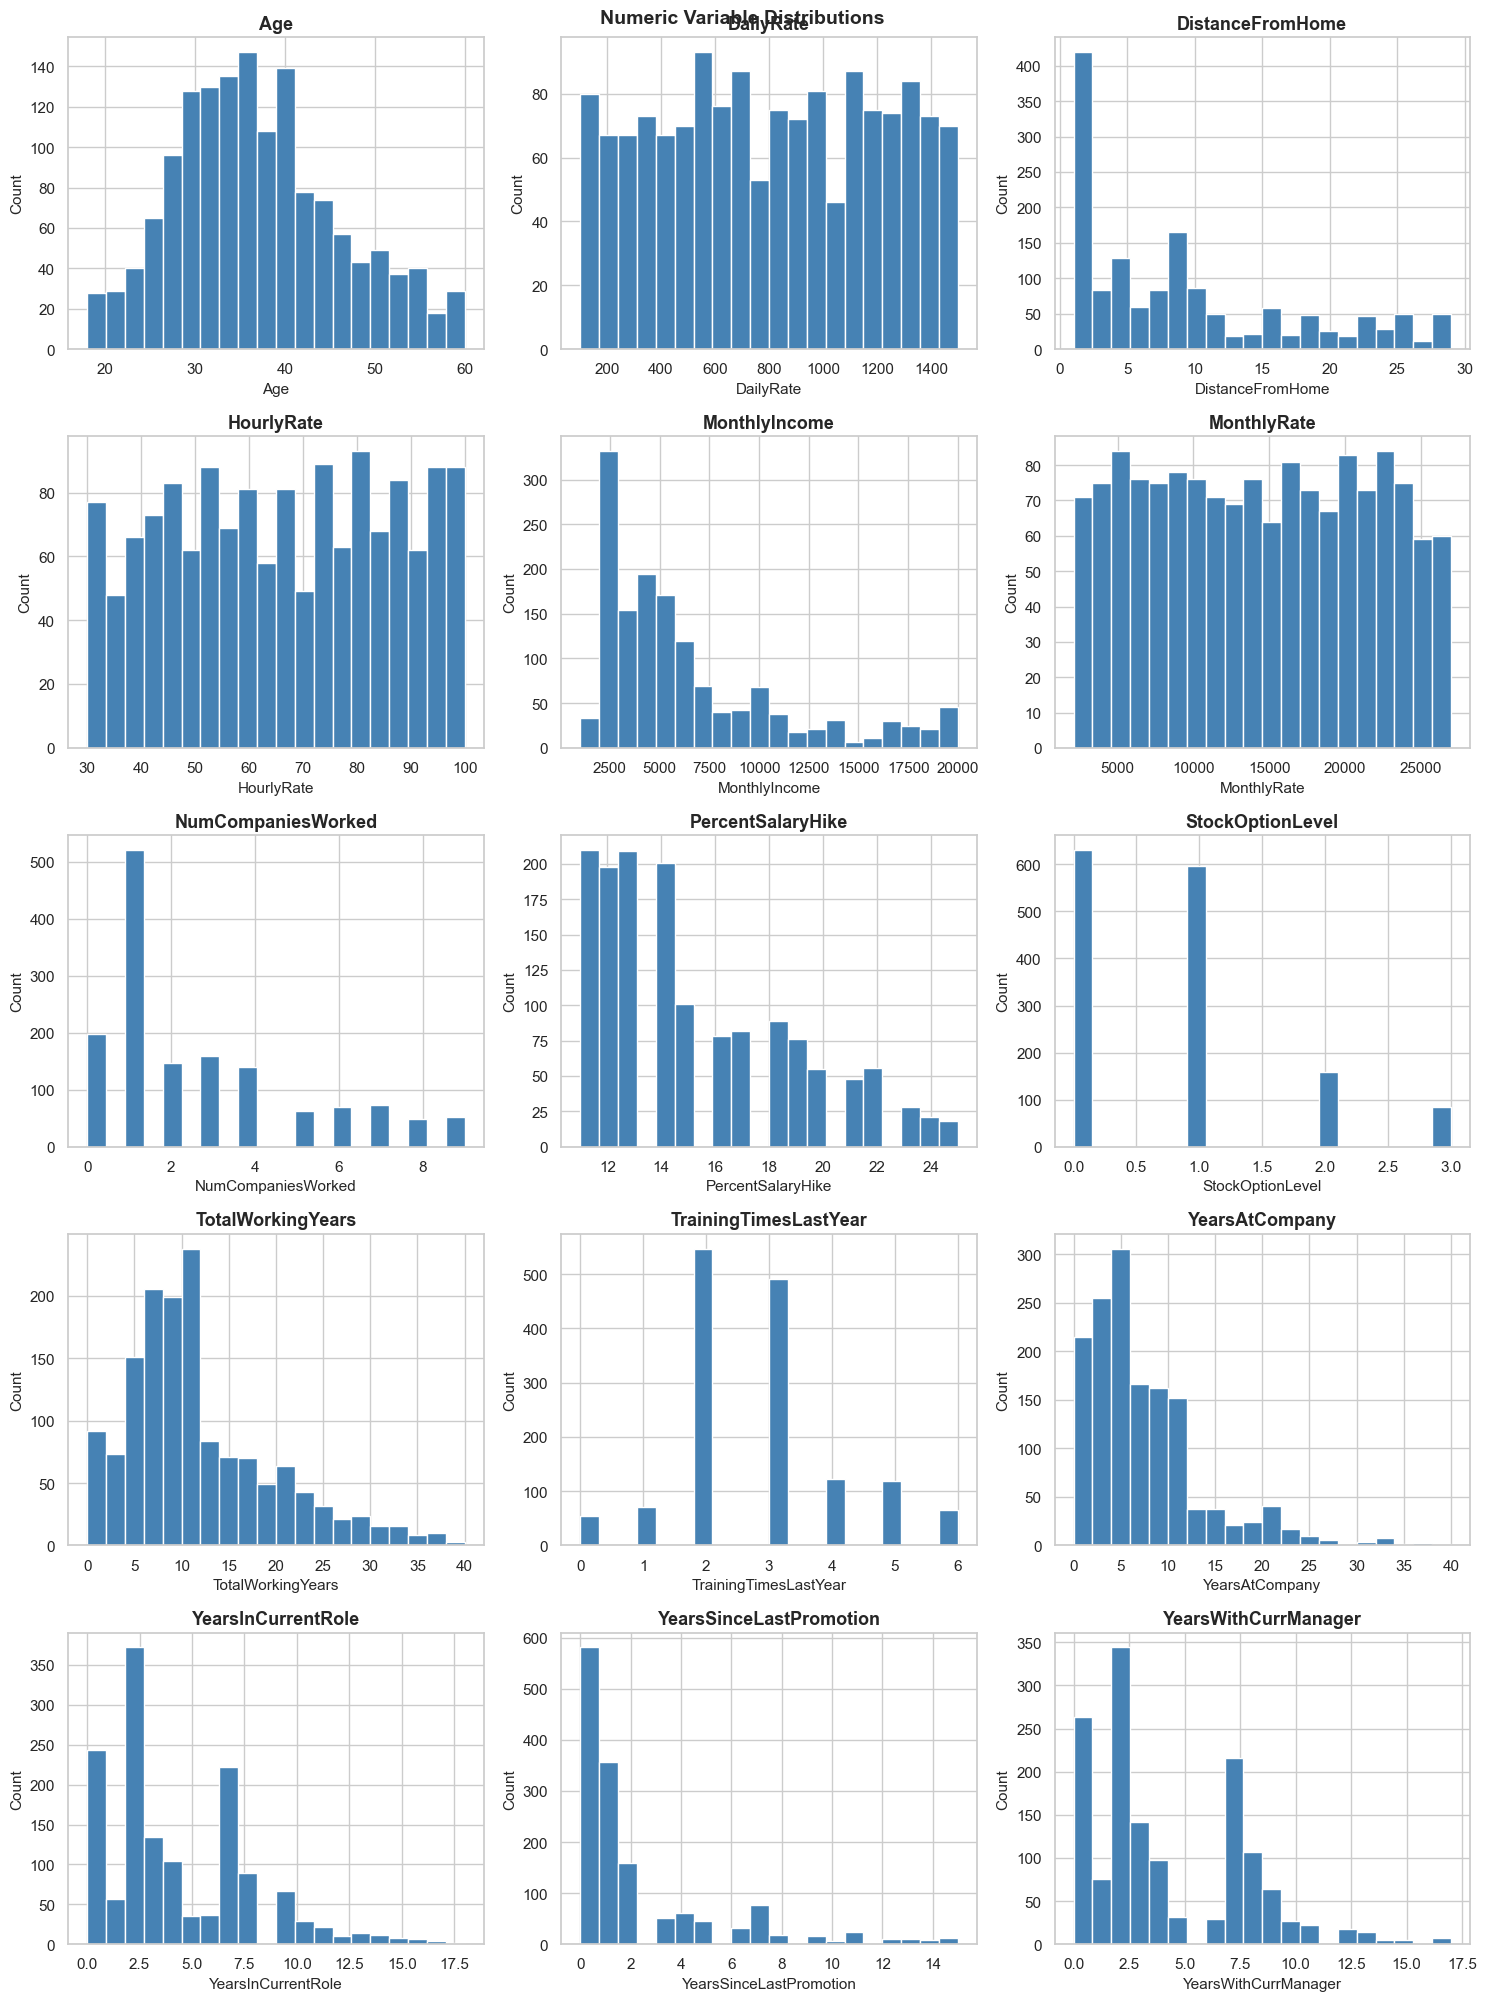

In [45]:
# Loop: histogram for each numeric variable
num_cols_plot = [c for c in num_cols if c not in ['AgeBand']]
fig, axes = plt.subplots(len(num_cols_plot)//3 + 1, 3, figsize=(15, 4*((len(num_cols_plot)//3)+1)))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Categorical variables — value counts
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Attrition']
print("Categorical / ordinal variables:", cat_cols)

Categorical / ordinal variables: ['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance', 'AgeBand']


In [47]:
# Summary table for all categorical variables
for col in cat_cols:
    print(f"\n{'='*45}")
    print(f"  {col}")
    print(f"{'='*45}")
    counts = df[col].value_counts()
    props  = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Percent (%)': props}).to_string())


  BusinessTravel
                   Count  Percent (%)
BusinessTravel                       
Travel_Rarely       1043         71.0
Travel_Frequently    277         18.8
Non-Travel           150         10.2

  Department
                        Count  Percent (%)
Department                                
Research & Development    961         65.4
Sales                     446         30.3
Human Resources            63          4.3

  Education
               Count  Percent (%)
Education                        
Bachelor         572         38.9
Master           398         27.1
College          282         19.2
Below College    170         11.6
Doctor            48          3.3

  EducationField
                  Count  Percent (%)
EducationField                      
Life Sciences       606         41.2
Medical             464         31.6
Marketing           159         10.8
Technical Degree    132          9.0
Other                82          5.6
Human Resources      27          1.